# **Assignment 2**

---
**Course Instructor: Sir Ali Raza**

**Course: Natural Language Processing**

* Roll Number: 22F-3438
* Roll Number: 22F-3442

---
*Topic: Conversational Chatbot using Transformer-based Encoder-Decoder Architecture*

# 1. Data Exploration
*Loading libraries for data exploration and preprocessing the data*

In [ ]:
import numpy as np
import pandas as pd
import os

In [ ]:
file_path = '/content/final_main_dataset.tsv'
df = pd.read_csv(file_path, sep='\t')
df.head()

,client_id,path,sentence,up_votes,down_votes,age,gender,accents,variant,locale,segment
0,e53f84d151d6cc6d45a57decde08a99efe47d7751a4ca6...,common_voice_ur_31771683.mp3,کبھی کبھار ہی خیالی پلاو بناتا ہوں,2,0,twenties,male,NaN,NaN,ur,NaN
1,e53f84d151d6cc6d45a57decde08a99efe47d7751a4ca6...,common_voice_ur_31771684.mp3,اور پھر ممکن ہے کہ پاکستان بھی ہو,2,1,twenties,male,NaN,NaN,ur,NaN
2,e53f84d151d6cc6d45a57decde08a99efe47d7751a4ca6...,common_voice_ur_31771685.mp3,یہ فیصلہ بھی گزشتہ دو سال میں,2,0,twenties,male,NaN,NaN,ur,NaN
3,e53f84d151d6cc6d45a57decde08a99efe47d7751a4ca6...,common_voice_ur_31771730.mp3,ان کے بلے بازوں کے سامنے ہو گا,3,0,twenties,male,NaN,NaN,ur,NaN
4,e53f84d151d6cc6d45a57decde08a99efe47d7751a4ca6...,common_voice_ur_31771732.mp3,آبی جانور میں بطخ بگلا اور دُوسْرا آبی پرندہ ش...,3,0,twenties,male,NaN,NaN,ur,NaN


In [ ]:
df.shape

(20000, 11)

In [ ]:
df.columns

Index(['client_id', 'path', 'sentence', 'up_votes', 'down_votes', 'age',
       'gender', 'accents', 'variant', 'locale', 'segment'],
      dtype='object')

In [ ]:
df.tail(10)

,client_id,path,sentence,up_votes,down_votes,age,gender,accents,variant,locale,segment
19990,ec4c510f65c3c4d7558d25f4888b493a320e94b9929ce8...,common_voice_ur_31842230.mp3,ایک ہزار روپے سے شروع کمپنی لاکھ کروڑ کی مالک ...,4,0,NaN,NaN,"Fluent, Native Urdu Speaker",NaN,ur,NaN
19991,ec4c510f65c3c4d7558d25f4888b493a320e94b9929ce8...,common_voice_ur_31842231.mp3,اس کے پیروں میں بیٹھ گیا۔,4,0,NaN,NaN,"Fluent, Native Urdu Speaker",NaN,ur,NaN
19992,ec4c510f65c3c4d7558d25f4888b493a320e94b9929ce8...,common_voice_ur_31842233.mp3,براہ راست پروازوں سے سعودی عرب اور مصر کے درمی...,4,0,NaN,NaN,"Fluent, Native Urdu Speaker",NaN,ur,NaN
19993,ec4c510f65c3c4d7558d25f4888b493a320e94b9929ce8...,common_voice_ur_31842264.mp3,ٹام کار کے حادثے میں بچ گیا تھا۔,4,0,NaN,NaN,"Fluent, Native Urdu Speaker",NaN,ur,NaN
19994,ec4c510f65c3c4d7558d25f4888b493a320e94b9929ce8...,common_voice_ur_31842265.mp3,قبروں پر آج بھی پھول چڑھائے جا رہے ہیں,4,0,NaN,NaN,"Fluent, Native Urdu Speaker",NaN,ur,NaN
19995,ec4c510f65c3c4d7558d25f4888b493a320e94b9929ce8...,common_voice_ur_31842266.mp3,اسٹینڈرڈ کرنسی فارمیٹ,4,0,NaN,NaN,"Fluent, Native Urdu Speaker",NaN,ur,NaN
19996,ec4c510f65c3c4d7558d25f4888b493a320e94b9929ce8...,common_voice_ur_31842267.mp3,اس نے معاملے پر دوبارہ غور کِیا,4,2,NaN,NaN,"Fluent, Native Urdu Speaker",NaN,ur,NaN
19997,ec4c510f65c3c4d7558d25f4888b493a320e94b9929ce8...,common_voice_ur_31842268.mp3,مگر ان بیٹسمینوں پر تنقید کرنے کے بجائے,4,0,NaN,NaN,"Fluent, Native Urdu Speaker",NaN,ur,NaN
19998,ec4c510f65c3c4d7558d25f4888b493a320e94b9929ce8...,common_voice_ur_31842299.mp3,ایک بہادر جرنیل دوسرے کی قدر جانتا ہے,4,0,NaN,NaN,"Fluent, Native Urdu Speaker",NaN,ur,NaN
19999,ec4c510f65c3c4d7558d25f4888b493a320e94b9929ce8...,common_voice_ur_31842300.mp3,انسان پر لازم ہے کہ وہ اللہ تعالی کی وحدانیت ک...,4,0,NaN,NaN,"Fluent, Native Urdu Speaker",NaN,ur,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   client_id   20000 non-null  object 
 1   path        20000 non-null  object 
 2   sentence    20000 non-null  object 
 3   up_votes    20000 non-null  int64  
 4   down_votes  20000 non-null  int64  
 5   age         16198 non-null  object 
 6   gender      16198 non-null  object 
 7   accents     2533 non-null   object 
 8   variant     0 non-null      float64
 9   locale      20000 non-null  object 
 10  segment     0 non-null      float64
dtypes: float64(2), int64(2), object(7)
memory usage: 1.7+ MB


In [ ]:
df.describe()

,up_votes,down_votes,variant,segment
count,20000.00000,20000.000000,0.0,0.0
mean,4.04610,0.353950,NaN,NaN
std,3.66739,0.977352,NaN,NaN
min,2.00000,0.000000,NaN,NaN
25%,2.00000,0.000000,NaN,NaN
50%,2.00000,0.000000,NaN,NaN
75%,4.00000,0.000000,NaN,NaN
max,51.00000,18.000000,NaN,NaN


In [ ]:
df.drop(['client_id', 'path', 'variant', 'locale', 'segment', 'gender', 'age', 'accents'], axis=1, inplace=True)
df.head(10)

,sentence,up_votes,down_votes
0,کبھی کبھار ہی خیالی پلاو بناتا ہوں,2,0
1,اور پھر ممکن ہے کہ پاکستان بھی ہو,2,1
2,یہ فیصلہ بھی گزشتہ دو سال میں,2,0
3,ان کے بلے بازوں کے سامنے ہو گا,3,0
4,آبی جانور میں بطخ بگلا اور دُوسْرا آبی پرندہ ش...,3,0
5,اِس طےشدہ مدت میں میرے ذمے پڑھانے کا کام کافی ...,2,0
6,فلمیں دیکھنی ہوں۔,2,0
7,دوسرا اس وجہ سے کہ اس کی پشت پر ذرائع ابلاغ ہیں۔,2,1
8,اسکے معانی پر اور مفہوم پر کبھی غورکیا بھی نہیں,2,0
9,ماتحت عدالتیں کس خوف کا شکار تھیں؟,2,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   sentence    20000 non-null  object
 1   up_votes    20000 non-null  int64 
 2   down_votes  20000 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 468.9+ KB


In [ ]:
df.describe()

,up_votes,down_votes
count,20000.00000,20000.000000
mean,4.04610,0.353950
std,3.66739,0.977352
min,2.00000,0.000000
25%,2.00000,0.000000
50%,2.00000,0.000000
75%,4.00000,0.000000
max,51.00000,18.000000


In [ ]:
df.tail(20)

,sentence,up_votes,down_votes
19980,ان کو اپنے کام کی دھن ہوتی ہے۔,4,0
19981,وہ بیچارہ معزز ہونے کی ایکٹنگ کرتا,6,0
19982,پاکستان دو لخت کیا ہو اسے یوم دفاع منانے کا کو...,4,2
19983,بوندا باندی ہو یا بارش کا طوفان، دونوں کیفیت ب...,4,0
19984,یہاں تک کہ آپ واپس حقیقت کی دنیا میں لوٹ آتے ہیں۔,6,0
19985,پاکستان میں اسما,4,0
19986,سڑکیں بنانی ہوں۔,6,0
19987,یہی کچھ یہاں ہوا۔,8,0
19988,کورونا وائرس کیا,4,0
19989,یہ سلسلہ تو بہت پہلے رکنا چاہیے۔,4,0


**Adding line by line in the text**

In [ ]:
sentences = df['sentence'].dropna().astype(str).tolist()
for i in range(15):
    print(sentences[i])

کبھی کبھار ہی خیالی پلاو بناتا ہوں
اور پھر ممکن ہے کہ پاکستان بھی ہو
یہ فیصلہ بھی گزشتہ دو سال میں
ان کے بلے بازوں کے سامنے ہو گا
آبی جانور میں بطخ بگلا اور دُوسْرا آبی پرندہ شامل ہونا
اِس طےشدہ مدت میں میرے ذمے پڑھانے کا کام کافی ہلکا ہے
فلمیں دیکھنی ہوں۔
دوسرا اس وجہ سے کہ اس کی پشت پر ذرائع ابلاغ ہیں۔
اسکے معانی پر اور مفہوم پر کبھی غورکیا بھی نہیں
ماتحت عدالتیں کس خوف کا شکار تھیں؟
پانی کی ایک عجیب خاصیت تھی
چیئرمین پیس بی کی نیوزی لینڈ کو دورہ پاکستان کی پیشکش
سمیت پاکستان کے تمام بڑے شہروں کے
جو یَہاں کا جنگلات کےحسن کو چار چاند لگنا دینا ہونا
فلم اچھا بزنس نہ کرتی ہو۔


In simple text file format

In [ ]:
with open("sentences.txt", "w", encoding="utf-8") as f:
    for line in sentences:
        f.write(line.strip() + "\n")

In JSON format for quick access

In [ ]:
import json

with open("sentences.jsonl", "w", encoding="utf-8") as f:
    for i, s in enumerate(sentences):
        record = {"id": i, "sentence": s}
        f.write(json.dumps(record) + "\n")

In [ ]:
df1 = pd.read_json("/content/sentences.jsonl", lines=True)
df1.head()

,id,sentence
0,0,کبھی کبھار ہی خیالی پلاو بناتا ہوں
1,1,اور پھر ممکن ہے کہ پاکستان بھی ہو
2,2,یہ فیصلہ بھی گزشتہ دو سال میں
3,3,ان کے بلے بازوں کے سامنے ہو گا
4,4,آبی جانور میں بطخ بگلا اور دُوسْرا آبی پرندہ ش...


In [ ]:
with open("/content/sentences.txt", "r", encoding="utf-8") as f:
    sentences = [line.strip().strip("[]'\",") for line in f if line.strip()]

df2 = pd.DataFrame(sentences, columns=["sentence"])
df2.head()

,sentence
0,کبھی کبھار ہی خیالی پلاو بناتا ہوں
1,اور پھر ممکن ہے کہ پاکستان بھی ہو
2,یہ فیصلہ بھی گزشتہ دو سال میں
3,ان کے بلے بازوں کے سامنے ہو گا
4,آبی جانور میں بطخ بگلا اور دُوسْرا آبی پرندہ ش...


**Importing Libraries**

In [1]:
!pip install rouge

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from torch.cuda.amp import autocast, GradScaler
import re
import math
import json
from typing import List, Tuple, Optional, Dict, Any
import warnings
import os
from tqdm import tqdm
import random
from sklearn.model_selection import train_test_split
import pickle
import sentencepiece as spm
from dataclasses import dataclass, asdict
from datetime import datetime
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge import Rouge

***Seting seeds for reproducibility***

In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
warnings.filterwarnings('ignore')

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory Allocated: {torch.cuda.memory_allocated(0)/1024**2:.2f} MB")

Device: cuda
CUDA Available: True
GPU: Tesla T4
Memory Allocated: 0.00 MB


# 2. Preprocessing

*Tokenizing and making vocab*

In [5]:
import re
from typing import List

In [6]:
class UrduTextProcessor:
    """Urdu-specific text preprocessing"""

    def __init__(self):

        self.diacritics = [
            '\u064B', '\u064C', '\u064D', '\u064E', '\u064F',
            '\u0650', '\u0651', '\u0652', '\u0653', '\u0654',
            '\u0655', '\u0656', '\u0657', '\u0658', '\u0670'
        ]

        self.normalization_map = {
            'آ': 'ا', 'أ': 'ا', 'إ': 'ا',
            'ۀ': 'ہ', 'ة': 'ہ',
            'ي': 'ی', 'ك': 'ک',
        }

    def remove_diacritics(self, text: str) -> str:
        for diacritic in self.diacritics:
            text = text.replace(diacritic, '')
        return text

    def normalize_characters(self, text: str) -> str:
        for old_char, new_char in self.normalization_map.items():
            text = text.replace(old_char, new_char)
        return text

    def clean_text(self, text: str) -> str:
        text = ' '.join(text.split())
        text = re.sub(r'[^\u0600-\u06FF\u0750-\u077F\s۔،؟!]', '', text)
        text = self.normalize_characters(text)
        text = self.remove_diacritics(text)
        text = ' '.join(text.split())
        return text.strip()

    def preprocess(self, text: str) -> str:
        return self.clean_text(text)

processor = UrduTextProcessor()

In [ ]:

test_samples = [
    "آپ کیسے ہیں؟ میں ٹھیک ہوں۔",
    "یہ   بہت   اچھا   ہے",  # Extra spaces
    "123 English mixed text آپ",  # Mixed content
]

print("=== Urdu Text Processor Tests ===")
for i, sample in enumerate(test_samples, 1):
    cleaned = processor.preprocess(sample)
    print(f"\nTest {i}:")
    print(f"  Input:  '{sample}'")
    print(f"  Output: '{cleaned}'")
    print(f"  Length: {len(sample)} → {len(cleaned)} chars")

=== Urdu Text Processor Tests ===

Test 1:
  Input:  'آپ کیسے ہیں؟ میں ٹھیک ہوں۔'
  Output: 'اپ کیسے ہیں؟ میں ٹھیک ہوں۔'
  Length: 26 → 26 chars

Test 2:
  Input:  'یہ   بہت   اچھا   ہے'
  Output: 'یہ بہت اچھا ہے'
  Length: 20 → 14 chars

Test 3:
  Input:  '123 English mixed text آپ'
  Output: 'اپ'
  Length: 25 → 2 chars


**Cleaning and Tokenizing the sentences**

In [7]:
processor = UrduTextProcessor()

cleaned_sentences = [processor.clean_text(s) for s in sentences]
tokenized_sentences = [processor.tokenize_words(s) for s in cleaned_sentences]

print("Cleaned Sentences (First 3):")
for s in cleaned_sentences[:3]:
    print("*", s)

print("\nTokens of First Sentence:")
print(tokenized_sentences[0])

NameError: name 'sentences' is not defined

Saving the cleaned sentences in a separate file

In [8]:
clean_file = "urdu_clean_sentences.txt"
with open(clean_file, "w", encoding="utf-8") as f:
    for line in cleaned_sentences:
        f.write(line + "\n")

print(f"Cleaned data saved to: {clean_file}")

NameError: name 'cleaned_sentences' is not defined

**Building both word-level and sentence-level embeddings**

* Word-level Embedding using Word2Vec

* Visualize and test embeddings

* Sentence-level Embedding (via weighted average or custom encoder)

* Prepare prompt–response pairs (for training your Urdu chatbot later)

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
from gensim.models import Word2Vec

file_path = "/kaggle/working/urdu_clean_sentences.txt"

with open(file_path, "r", encoding="utf-8") as f:
    sentences = [line.strip() for line in f.readlines() if line.strip()]

# Tokenize
tokenized_sentences = [s.split() for s in sentences]

print(f" Loaded {len(sentences)} sentences")
print(" Example tokenized sentence:\n", tokenized_sentences[0])

ModuleNotFoundError: No module named 'gensim'

*Training a Word2Vec model for semantic relationship*

In [ ]:
# Train a Word2Vec model
word2vec_model = Word2Vec(
    sentences=tokenized_sentences,
    vector_size=100,      # embedding size (can increase later)
    window=5,             # context window
    min_count=1,          # keep all words
    workers=4,            # parallel threads
    sg=1,                 # skip-gram (better for small data)
    epochs=50             # more epochs for better convergence
)

# Save model for later
word2vec_model.save("urdu_word2vec.model")

print(" Word2Vec training complete!")
print(" Vocabulary size:", len(word2vec_model.wv))

NameError: name 'Word2Vec' is not defined

Testing on some random words.


Checking Urdu words and their most similar neighbors.


In [ ]:
# Pick some Urdu words to test
test_words = ['پاکستان', 'زندگی', 'دوست', 'وقت', 'خوبصورت']

for word in test_words:
    if word in word2vec_model.wv:
        print(f"\n {word} کے مشابہ الفاظ:")
        for sim_word, score in word2vec_model.wv.most_similar(word, topn=5):
            print(f"   {sim_word}  ({score:.3f})")
    else:
        print(f" Word '{word}' not found in vocabulary.")

NameError: name 'word2vec_model' is not defined

For making prompt-response pairs of the given general dataset.

In [ ]:
! pip install -U "transformers==4.45.2"


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 113.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 116.1 MB/s eta 0:00:00
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.1
    Uninstalling tokenizers-0.22.1:
      Successfully uninstalled tokenizers-0.22.1
  Attempting uninstall: transformers
    Found existing installation: transformers 4.57.1
    Uninstalling transformers-4.57.1:
      Successfully uninstalled transformers-4.57.1


In [ ]:
pip install -U sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 488.0/488.0 kB 13.1 MB/s eta 0:00:00
  Attempting uninstall: sentence-transformers
    Found existing installation: sentence-transformers 5.1.1
    Uninstalling sentence-transformers-5.1.1:
      Successfully uninstalled sentence-transformers-5.1.1


In [ ]:
print(len(cleaned_sentences))

20044


In [ ]:
!pip install -U "transformers==4.45.2" "sentence-transformers==3.0.1" "huggingface-hub==0.25.2"


  Using cached sentence_transformers-3.0.1-py3-none-any.whl.metadata (10 kB)
Using cached sentence_transformers-3.0.1-py3-none-any.whl (227 kB)
  Attempting uninstall: sentence-transformers
    Found existing installation: sentence-transformers 5.1.1
    Uninstalling sentence-transformers-5.1.1:
      Successfully uninstalled sentence-transformers-5.1.1


**Using K-means to check the similairy between each pair**

In [ ]:

from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
import numpy as np

# Step 1: Load multilingual embedding model
model = SentenceTransformer('sentence-transformers/LaBSE')
embeddings = model.encode(sentences, convert_to_numpy=True, show_progress_bar=False)

# Step 2: Cluster sentences
num_clusters = 4  # tweak based on dataset size
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
labels = kmeans.fit_predict(embeddings)

# Step 3: Group sentences by cluster
clusters = {}
for label, sentence in zip(labels, sentences):
    clusters.setdefault(label, []).append(sentence)

print("Embeddings Shape:", embeddings.shape)


Embeddings Shape: (20000, 768)


Checking Similarity

In [ ]:
# Step 4: Create prompt–response pairs from same cluster
pairs = []
for label, group in clusters.items():
    if len(group) > 1:
        for i in range(len(group) - 1):
            pairs.append((group[i], group[i + 1]))

# Step 5: Display generated pairs
for i, (prompt, response) in enumerate(pairs[:10]):
    print(f"Prompt: {prompt}")
    print(f"Response: {response}")
    print("-" * 60)

Prompt: کبھی کبھار ہی خیالی پلاو بناتا ہوں
Response: اور پھر ممکن ہے کہ پاکستان بھی ہو
------------------------------------------------------------
Prompt: اور پھر ممکن ہے کہ پاکستان بھی ہو
Response: یہ فیصلہ بھی گزشتہ دو سال میں
------------------------------------------------------------
Prompt: یہ فیصلہ بھی گزشتہ دو سال میں
Response: ان کے بلے بازوں کے سامنے ہو گا
------------------------------------------------------------
Prompt: ان کے بلے بازوں کے سامنے ہو گا
Response: اِس طےشدہ مدت میں میرے ذمے پڑھانے کا کام کافی ہلکا ہے
------------------------------------------------------------
Prompt: اِس طےشدہ مدت میں میرے ذمے پڑھانے کا کام کافی ہلکا ہے
Response: اسکے معانی پر اور مفہوم پر کبھی غورکیا بھی نہیں
------------------------------------------------------------
Prompt: اسکے معانی پر اور مفہوم پر کبھی غورکیا بھی نہیں
Response: پانی کی ایک عجیب خاصیت تھی
------------------------------------------------------------
Prompt: پانی کی ایک عجیب خاصیت تھی
Response: صرف کام کرو کھانا کھاؤ ٹی

The above simple cosine similarity doesn't yield a feasible output. Using How FAISS Works

* Normalize embeddings → makes L2 distance = cosine distance equivalence.

* Build index (e.g., IndexFlatIP) → stores vectors compactly.

* Search efficiently → returns top-k most similar embeddings with their distances.

In [ ]:
!pip install faiss-cpu


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 86.8 MB/s eta 0:00:00


In [ ]:
import faiss
import numpy as np
from sentence_transformers import SentenceTransformer

# Load model and encode
model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
embeddings = model.encode(cleaned_sentences, convert_to_numpy=True, show_progress_bar=False)

# Normalize for cosine similarity
faiss.normalize_L2(embeddings)

# Build FAISS index (L2 or inner product)
index = faiss.IndexFlatIP(embeddings.shape[1])
index.add(embeddings)

# Query example
query = "کیہ بات اب عیاں ہے"
query_emb = model.encode([query], convert_to_numpy=True)
faiss.normalize_L2(query_emb)

# Retrieve top 5 similar sentences
D, I = index.search(query_emb, 5)

for idx in I[0]:
    print(sentences[idx])


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

یہ بات اب عیاں ہے۔
یہ بات اب عیاں ہے۔
یہ بات اب عیاں ہے۔
اب بڈھا ھو گیا ھے
اب بڈھا ھو گیا ھے


In [ ]:
from tqdm import tqdm
# Load the multilingual model
model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

# Suppose cleaned_sentences = your Urdu sentences list
sentences = list(set(cleaned_sentences))  # remove duplicates
print(f"Total unique sentences: {len(sentences)}")

# Step 1: Encode all sentences
embeddings = model.encode(sentences, convert_to_numpy=True, show_progress_bar=True)
faiss.normalize_L2(embeddings)

# Step 2: Build FAISS index
index = faiss.IndexFlatIP(embeddings.shape[1])
index.add(embeddings)

# Step 3: Find top-k similar sentences for each (k=2 for now)
_, indices = index.search(embeddings, 2)

# Step 4: Build prompt–response pairs
pairs = []
for i, (prompt_idx, resp_idx) in enumerate(zip(range(len(sentences)), indices[:, 1])):
    prompt = sentences[prompt_idx]
    response = sentences[resp_idx]

    # Optional filter: avoid identical or meaningless duplicates
    if prompt != response and len(response.strip()) > 3:
        pairs.append({"prompt": prompt, "response": response})

# Step 5: Save as CSV
df = pd.DataFrame(pairs)
df.to_csv("urdu_prompt_response_pairs.csv", index=False, encoding="utf-8-sig")

print(f" Saved {len(df)} prompt–response pairs to urdu_prompt_response_pairs.csv")
df.sample(10)

Total unique sentences: 10697


Batches:   0%|          | 0/335 [00:00<?, ?it/s]

 Saved 10679 prompt–response pairs to urdu_prompt_response_pairs.csv


,prompt,response
6343,انحصار کو کم کرنے کے لیے,ہونٹوں سے مسکان چھن جائے
668,پاکستان جانے کےلئے بھی پاکستان کا ویزہ ایمبیسی...,اسلام اباد تجارتی سفارت کاری کام کرگئی
1780,اج ہفتے کا دن ہے۔,مگر جب دوسرے اینڈ پہ
2930,کتابوں کی اس دکان میں یہ دیوار ان بک مارکس کےل...,جب چھپے گی اور بک سٹالوں پہ ائے گی۔
1523,نیا کام کرنے والےافراد ذہنی دباؤ کا شکار,کچھ روزگار کا مسئلہ۔
2177,ویسٹ انڈیز کی ٹیم کراچی پہنچ گئی,دوسرا وویمن کرکٹ ون ڈےویسٹ انڈیز نےپاکستان کوہ...
346,ان کا خیال ہے کہ اب ان کو ایک اور موقع مل گیا ہے۔,تو میرا خیال ہے کہ انہیں یہ موقع ضرور ملنا چاہیے۔
6367,تم کہاں ہو؟,اپ کہاں سے ہیں
1512,ہر مرتبہ چومکھی لڑائی لڑنے والے کپتان کے لتے ل...,اور کپتان کا سب سے بڑاجرم میچ کو فنش نہ کرنا ہے ۔
8622,اقتدار میں ظاہر ہے۔,تو اقتدار میں۔


In [ ]:
print(len(cleaned_sentences))

20044


In [ ]:
# ========================================
# IMPROVED SPAN CORRUPTION FOR URDU TEXT
# ========================================
import random
import re
from typing import List, Tuple, Optional
import pandas as pd

class UrduSpanCorruption:
    """
    T5-Style Span Corruption for Urdu text augmentation.
    Improved version with proper span sampling and multiple noise levels.
    """

    def __init__(self,
                 noise_density: float = 0.15,
                 mean_span_length: int = 3):
        """
        Args:
            noise_density: Fraction of tokens to corrupt (0.0 to 1.0)
            mean_span_length: Average length of corrupted spans
        """
        self.noise_density = noise_density
        self.mean_span_length = mean_span_length

    def create_span_corruption(self,
                               sentence: str,
                               noise_density: Optional[float] = None) -> Tuple[Optional[str], Optional[str]]:
        """
        Create span corruption pairs like T5.

        Args:
            sentence: Original sentence
            noise_density: Fraction of tokens to corrupt (overrides default if provided)

        Returns:
            Tuple of (corrupted_input, target_output)
            Returns (None, None) if sentence is too short
        """
        words = sentence.split()
        n_words = len(words)

        if n_words < 5:
            return None, None

        # Use provided noise density or default
        density = noise_density if noise_density is not None else self.noise_density

        # Calculate number of tokens to corrupt
        n_corrupt = max(1, int(n_words * density))

        # Generate span positions
        spans_to_mask = []
        remaining = n_corrupt

        while remaining > 0:
            # Random span length using exponential distribution
            span_len = min(remaining, max(1, int(random.expovariate(1.0 / self.mean_span_length))))

            # Random start position
            max_start = n_words - span_len
            if max_start < 0:
                break

            start = random.randint(0, max_start)
            end = start + span_len

            # Check for overlap with existing spans
            overlap = False
            for existing_start, existing_end, _ in spans_to_mask:
                if not (end <= existing_start or start >= existing_end):
                    overlap = True
                    break

            if not overlap:
                spans_to_mask.append((start, end, len(spans_to_mask)))
                remaining -= span_len

        if not spans_to_mask:
            return None, None

        # Sort spans by position
        spans_to_mask.sort(key=lambda x: x[0])

        # Build corrupted input and target
        corrupted_words = []
        target_words = []
        last_pos = 0

        for start, end, span_id in spans_to_mask:
            # Add words before span
            corrupted_words.extend(words[last_pos:start])

            # Add mask token to corrupted input
            corrupted_words.append(f"[MASK{span_id}]")

            # Add span marker and masked words to target
            target_words.append(f"[SPAN{span_id}]")
            target_words.extend(words[start:end])

            last_pos = end

        # Add remaining words to corrupted input
        corrupted_words.extend(words[last_pos:])

        corrupted_input = ' '.join(corrupted_words)
        target_output = ' '.join(target_words)

        return corrupted_input, target_output

    def generate_corrupted_dataset(self,
                                   sentences: List[str],
                                   noise_levels: List[float] = [0.15, 0.25, 0.35],
                                   min_words: int = 8,
                                   max_words: int = 40,
                                   min_chars: int = 30,
                                   min_target_words: int = 3) -> pd.DataFrame:
        """
        Generate complete span corruption dataset with multiple noise levels.

        Args:
            sentences: List of input sentences
            noise_levels: List of noise densities to apply
            min_words: Minimum words per sentence
            max_words: Maximum words per sentence
            min_chars: Minimum characters per sentence
            min_target_words: Minimum words in target output

        Returns:
            DataFrame with columns: original, corrupted_input, target_output, noise_level
        """
        # Filter quality sentences
        quality_sentences = [
            s for s in sentences
            if min_words <= len(s.split()) <= max_words
            and len(s) >= min_chars
            and s.strip()
        ]

        print(f"Quality sentences: {len(quality_sentences):,} / {len(sentences):,}")

        data = []

        for sent in quality_sentences:
            # Create multiple corruptions with different noise levels
            for noise_level in noise_levels:
                corrupted, target = self.create_span_corruption(sent, noise_density=noise_level)

                # Validate output
                if corrupted and target and len(target.split()) >= min_target_words:
                    data.append({
                        'original': sent,
                        'corrupted_input': corrupted,
                        'target_output': target,
                        'noise_level': noise_level
                    })

        return pd.DataFrame(data)


# ============ USAGE WITH YOUR DATA ============

# Initialize span corruptor
span_corruptor = UrduSpanCorruption(
    noise_density=0.15,      # Default noise level
    mean_span_length=3       # Average span length
)

# ============ TEST WITH EXAMPLES ============
print("=" * 80)
print("SPAN CORRUPTION EXAMPLES (T5-STYLE)")
print("=" * 80)


SPAN CORRUPTION EXAMPLES (T5-STYLE)


In [ ]:

test_sentences = [
    "یہ ایک بہت اچھا دن ہے اور میں بہت خوش ہوں اور سب کچھ ٹھیک ہے",
    "پاکستان ایک خوبصورت ملک ہے جہاں مختلف زبانیں بولی جاتی ہیں",
    "آج کا موسم بہت اچھا ہے اور سورج چمک رہا ہے آسمان صاف ہے"
]

for i, sentence in enumerate(test_sentences, 1):
    print(f"\n{'='*80}")
    print(f"Example {i}:")
    print(f"Original: {sentence}")
    print(f"\nDifferent Noise Levels:")

    for noise in [0.15, 0.25, 0.35]:
        corrupted, target = span_corruptor.create_span_corruption(sentence, noise_density=noise)
        print(f"\n  Noise {int(noise*100)}%:")
        print(f"    Corrupted: {corrupted}")
        print(f"    Target:    {target}")

# ============ APPLY TO YOUR CLEANED SENTENCES ============

print("\n" + "=" * 80)
print("GENERATING SPAN CORRUPTION DATASET")
print("=" * 80)

# Generate corrupted dataset with multiple noise levels
corrupted_df = span_corruptor.generate_corrupted_dataset(
    sentences=cleaned_sentences,
    noise_levels=[0.15, 0.25, 0.35],  # 15%, 25%, 35% corruption
    min_words=8,                       # Minimum 8 words
    max_words=40,                      # Maximum 40 words
    min_chars=30,                      # Minimum 30 characters
    min_target_words=3                 # Minimum 3 words in target
)

print(f"\nGenerated {len(corrupted_df):,} span-corrupted training examples")

# ============ DISPLAY SAMPLE ============
print("\n" + "=" * 80)
print("SAMPLE OF GENERATED DATA")
print("=" * 80)

sample_df = corrupted_df.sample(min(10, len(corrupted_df)))
for idx, row in sample_df.iterrows():
    print(f"\nOriginal:         {row['original']}")
    print(f"Corrupted Input:  {row['corrupted_input']}")
    print(f"Target Output:    {row['target_output']}")
    print(f"Noise Level:      {row['noise_level']}")
    print("-" * 80)

# ============ SAVE TO CSV ============
output_path = "urdu_span_corrupted_t5_style.csv"
corrupted_df.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"\n✓ Saved span-corrupted pairs to: {output_path}")

# ============ DETAILED STATISTICS ============
print("\n" + "=" * 80)
print("DATASET STATISTICS")
print("=" * 80)

print(f"\nTotal examples: {len(corrupted_df):,}")
print(f"\nExamples per noise level:")
for noise_level in [0.15, 0.25, 0.35]:
    count = len(corrupted_df[corrupted_df['noise_level'] == noise_level])
    print(f"  {int(noise_level*100)}% noise: {count:,} examples")

print(f"\nAverage lengths:")
print(f"  Original:        {corrupted_df['original'].str.split().str.len().mean():.1f} words")
print(f"  Corrupted Input: {corrupted_df['corrupted_input'].str.split().str.len().mean():.1f} words")
print(f"  Target Output:   {corrupted_df['target_output'].str.split().str.len().mean():.1f} words")

# Analyze mask token usage
mask_counts = corrupted_df['corrupted_input'].str.count(r'\[MASK\d+\]')
print(f"\nMask tokens per example:")
print(f"  Mean: {mask_counts.mean():.2f}")
print(f"  Min:  {mask_counts.min()}")
print(f"  Max:  {mask_counts.max()}")

print("\n" + "=" * 80)
print("✓ Span corruption complete!")
print("=" * 80)


Example 1:
Original: یہ ایک بہت اچھا دن ہے اور میں بہت خوش ہوں اور سب کچھ ٹھیک ہے

Different Noise Levels:

  Noise 15%:
    Corrupted: یہ [MASK0] بہت [MASK1] دن ہے اور میں بہت خوش ہوں اور سب کچھ ٹھیک ہے
    Target:    [SPAN0] ایک [SPAN1] اچھا

  Noise 25%:
    Corrupted: یہ ایک بہت اچھا دن ہے [MASK0] ہوں اور سب کچھ ٹھیک ہے
    Target:    [SPAN0] اور میں بہت خوش

  Noise 35%:
    Corrupted: یہ ایک بہت اچھا دن [MASK1] [MASK0] ہوں اور سب کچھ ٹھیک ہے
    Target:    [SPAN1] ہے اور میں بہت [SPAN0] خوش

Example 2:
Original: پاکستان ایک خوبصورت ملک ہے جہاں مختلف زبانیں بولی جاتی ہیں

Different Noise Levels:

  Noise 15%:
    Corrupted: پاکستان [MASK0] خوبصورت ملک ہے جہاں مختلف زبانیں بولی جاتی ہیں
    Target:    [SPAN0] ایک

  Noise 25%:
    Corrupted: پاکستان [MASK1] خوبصورت [MASK0] ہے جہاں مختلف زبانیں بولی جاتی ہیں
    Target:    [SPAN1] ایک [SPAN0] ملک

  Noise 35%:
    Corrupted: پاکستان [MASK0] ہے جہاں مختلف زبانیں بولی جاتی ہیں
    Target:    [SPAN0] ایک خوبصورت ملک

Example 3:
Origin

20k+ sentences and 384-dimensional embeddings, we can’t plot directly.
Instead, use dimensionality reduction:

🧩 UMAP → best for preserving semantic structure (recommended)

🎨 t-SNE → good for local similarity (but slower)

⚡ PCA → fast for rough preview

In [ ]:
import matplotlib.pyplot as plt
import umap
import seaborn as sns


# Assuming 'embeddings' and 'sentences' exist
# Reduce to 2D using UMAP for visualization
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42)
embeddings_2d = reducer.fit_transform(embeddings)

# Create DataFrame for plotting
df_vis = pd.DataFrame(embeddings_2d, columns=["x", "y"])
df_vis["sentence"] = cleaned_sentences

ValueError: Length of values (20000) does not match length of index (10697)

In [ ]:
csv_path: str = '/kaggle/input/urdu-transcription-20k/urdu_prompt_response_pairs.csv'
df = pd.read_csv(csv_path, encoding='utf-8')
df.head()

,prompt,response
0,اتنا انوکھا نہیں۔,بے وقوف نہیں۔
1,نہ کہ اس سارے حساب کتاب سے پہلے۔,اداروں سے تو حساب برابر نہیں ہوا۔
2,تو دوسروں کے قبضے کی کیا بات کرنی؟,، اپنے گریبان میں جھانکنے کی بجائے دوسروں کو ب...
3,ازادی اظہار کیلئے اواز اٹھاتے رہے۔,اس کے بول کچھ یوں ہیں۔
4,اندازہ ھے کہ جاپان میں اگلے دس سالوں میں بجلی ...,بجلی سے چلنے والی گاڑی اس وقت جاپان میں خریدی ...


In [ ]:
print("help")

help


In [ ]:
!pip install rouge

In [ ]:
# ============================================
# CELL: Switch to Extra-Large Model Configuration
# ============================================

# Stop current training and reset
print("Switching to Extra-Large Model Configuration...\n")

# Create new config for extra-large model
config_xlarge = TrainingConfig.xlarge()

print(f"Extra-Large Model Configuration:")
print(f"  d_model: {config_xlarge.d_model}")
print(f"  n_heads: {config_xlarge.n_heads}")
print(f"  n_encoder_layers: {config_xlarge.n_encoder_layers}")
print(f"  n_decoder_layers: {config_xlarge.n_decoder_layers}")
print(f"  d_ff: {config_xlarge.d_ff}")
print(f"  batch_size: {config_xlarge.batch_size}")
print(f"  num_epochs: {config_xlarge.num_epochs}\n")

# Reinitialize model with extra-large config
model_xlarge = UrduTransformerChatbot(tokenizer.get_vocab_size(), config_xlarge).to(device)
total_params_xlarge = sum(p.numel() for p in model_xlarge.parameters())
print(f"Extra-Large Model Parameters: {total_params_xlarge:,}\n")

# Recreate data loaders with new batch size
train_loader_xlarge = DataLoader(train_dataset, batch_size=config_xlarge.batch_size, shuffle=True, drop_last=True)
val_loader_xlarge = DataLoader(val_dataset, batch_size=config_xlarge.batch_size, shuffle=False, drop_last=True)
test_loader_xlarge = DataLoader(test_dataset, batch_size=config_xlarge.batch_size, shuffle=False, drop_last=True)

print(f"Train batches: {len(train_loader_xlarge)}")
print(f"Val batches: {len(val_loader_xlarge)}")
print(f"Test batches: {len(test_loader_xlarge)}\n")

# Recreate optimizer and scheduler for extra-large model
optimizer_xlarge = optim.AdamW(model_xlarge.parameters(), lr=config_xlarge.learning_rate,
                                betas=(0.9, 0.98), eps=1e-9)
scheduler_xlarge = get_lr_scheduler(optimizer_xlarge, config_xlarge.warmup_steps)

# Recreate trainer
trainer_xlarge = EnhancedTrainer(model_xlarge, optimizer_xlarge, criterion, scheduler_xlarge, device, config_xlarge)

print("✓ Extra-Large model ready for training!\n")


# ============================================
# CELL: Train Extra-Large Model
# ============================================

curriculum_xlarge = CurriculumLearning(initial_length=20, max_length=config_xlarge.max_seq_length,
                                       epochs=config_xlarge.num_epochs)

print("="*60)
print("TRAINING EXTRA-LARGE MODEL")
print("="*60)
print(f"Configuration: Extra-Large (XLarge)")
print(f"Vocab size: {tokenizer.get_vocab_size()}")
print(f"Model params: {total_params_xlarge:,}\n")

for epoch in range(config_xlarge.num_epochs):
    print(f"\nEpoch {epoch+1}/{config_xlarge.num_epochs}")

    # Get curriculum learning length
    if config_xlarge.use_curriculum_learning:
        current_len = curriculum_xlarge.get_length_for_epoch(epoch)
        print(f"Curriculum length: {current_len}")

    # Train
    train_loss = trainer_xlarge.train_epoch(train_loader_xlarge, epoch)
    print(f"Train Loss: {train_loss:.4f}")

    # Validate
    if (epoch + 1) % config_xlarge.eval_every == 0:
        val_loss = trainer_xlarge.evaluate(val_loader_xlarge)
        print(f"Val Loss: {val_loss:.4f}")

        if val_loss < trainer_xlarge.best_val_loss:
            trainer_xlarge.best_val_loss = val_loss
            torch.save(model_xlarge.state_dict(), 'best_model_xlarge.pt')
            print("✓ New best extra-large model saved!")

    # Save checkpoint
    if (epoch + 1) % config_xlarge.save_every == 0:
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model_xlarge.state_dict(),
            'optimizer_state_dict': optimizer_xlarge.state_dict(),
            'config': asdict(config_xlarge)
        }
        torch.save(checkpoint, f'checkpoint_xlarge_epoch_{epoch+1}.pt')

print("\n" + "="*60)
print("EXTRA-LARGE MODEL TRAINING COMPLETE!")
print("="*60)
print(f"Best validation loss: {trainer_xlarge.best_val_loss:.4f}\n")

# Plot extra-large model training curves
trainer_xlarge.plot_training_curves(save_path='training_curves_xlarge.png')


# ============================================
# CELL: Model Comparison - All Three Sizes
# ============================================

print("\n" + "="*60)
print("MODEL SIZE COMPARISON")
print("="*60 + "\n")

comparison_data = {
    'Model': ['Baseline', 'Large', 'Extra-Large'],
    'd_model': [config.d_model, config_large.d_model, config_xlarge.d_model],
    'n_heads': [config.n_heads, config_large.n_heads, config_xlarge.n_heads],
    'Layers': [config.n_encoder_layers, config_large.n_encoder_layers, config_xlarge.n_encoder_layers],
    'Batch Size': [config.batch_size, config_large.batch_size, config_xlarge.batch_size],
    'Parameters (M)': [total_params/1e6, total_params_large/1e6, total_params_xlarge/1e6],
    'Best Val Loss': [trainer.best_val_loss, trainer_large.best_val_loss, trainer_xlarge.best_val_loss]
}

df_comparison = pd.DataFrame(comparison_data)
print(df_comparison.to_string(index=False))

# Visualize model sizes and performance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Model sizes
models = ['Baseline', 'Large', 'XLarge']
params = [total_params/1e6, total_params_large/1e6, total_params_xlarge/1e6]
colors = ['#3498db', '#e74c3c', '#2ecc71']

axes[0].bar(models, params, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
axes[0].set_ylabel('Parameters (Millions)', fontsize=12)
axes[0].set_title('Model Size Comparison', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')
for i, p in enumerate(params):
    axes[0].text(i, p + 2, f'{p:.1f}M', ha='center', fontweight='bold')

# Validation loss comparison
val_losses = [trainer.best_val_loss, trainer_large.best_val_loss, trainer_xlarge.best_val_loss]
axes[1].bar(models, val_losses, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
axes[1].set_ylabel('Best Validation Loss', fontsize=12)
axes[1].set_title('Performance Comparison', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
for i, loss in enumerate(val_losses):
    axes[1].text(i, loss + 0.01, f'{loss:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nComparison chart saved as: model_comparison.png")

In [ ]:
!rm -rf /kaggle/working/

rm: cannot remove '/kaggle/working/': Device or resource busy


# 3. Configuration System

*Setting up the configuration for different hyper parameters*

In [ ]:
@dataclass
class TrainingConfig:
    """Unified training configuration for all model sizes"""

    # Model Architecture (scaling parameters)
    d_model: int = 256
    n_heads: int = 2
    n_encoder_layers: int = 2
    n_decoder_layers: int = 2
    d_ff: int = 1024
    dropout: float = 0.2
    max_seq_length: int = 50

    # Tokenization
    vocab_size: int = 16000

    # Training
    batch_size: int = 32
    learning_rate: float = 1e-4
    num_epochs: int = 70
    warmup_steps: int = 200
    gradient_clip: float = 1.0
    teacher_forcing_ratio: float = 0.9
    label_smoothing: float = 0.1

    # Advanced Techniques (all enabled in baseline)
    use_relative_position: bool = True
    use_attention_regularization: bool = True
    attention_entropy_weight: float = 0.01
    attention_sparsity_weight: float = 0.001
    use_gradient_accumulation: bool = True
    accumulation_steps: int = 2
    use_mixed_precision: bool = False
    use_curriculum_learning: bool = True

    # Evaluation
    eval_every: int = 5
    save_every: int = 20

    @classmethod
    def baseline(cls):
        """Baseline with all advanced techniques"""
        return cls(
            d_model=512, n_heads=2, n_encoder_layers=2, n_decoder_layers=2,
            use_relative_position=True, use_attention_regularization=True,
            use_gradient_accumulation=True, use_curriculum_learning=True
        )

    @classmethod
    def large(cls):
        """Large model: increased d_model and layers"""
        return cls(
            d_model=512, n_heads=16, n_encoder_layers=4, n_decoder_layers=4,
            d_ff=2048, batch_size=16,
            use_relative_position=True, use_attention_regularization=True,
            use_gradient_accumulation=True, use_curriculum_learning=True
        )

    @classmethod
    def xlarge(cls):
        """Extra-large model: maximum capacity"""
        return cls(
            d_model=768, n_heads=12, n_encoder_layers=6, n_decoder_layers=6,
            d_ff=3072, batch_size=8, num_epochs=100,
            use_relative_position=True, use_attention_regularization=True,
            use_gradient_accumulation=True, use_curriculum_learning=True
        )


print("Configuration system ready!")
print(f"Baseline Config: d_model={TrainingConfig.baseline().d_model}, layers={TrainingConfig.baseline().n_encoder_layers}")
print(f"Large Config: d_model={TrainingConfig.large().d_model}, layers={TrainingConfig.large().n_encoder_layers}")
print(f"XLarge Config: d_model={TrainingConfig.xlarge().d_model}, layers={TrainingConfig.xlarge().n_encoder_layers}\n")



Configuration system ready!
Baseline Config: d_model=512, layers=2
Large Config: d_model=512, layers=4
XLarge Config: d_model=768, layers=6



# 4. SentencePiece Tokenization

* Using BPE

In [ ]:
class UrduSentencePieceTokenizer:
    """SentencePiece tokenizer for Urdu morphological richness"""

    def __init__(self, model_prefix: str = 'urdu_sp', vocab_size: int = 16000):
        self.model_prefix = model_prefix
        self.vocab_size = vocab_size
        self.sp = None

    def train(self, texts: List[str], processor: UrduTextProcessor):
        """Train SentencePiece on Urdu texts"""
        print(f"Training SentencePiece tokenizer (vocab_size={self.vocab_size})...")

        cleaned_texts = [processor.preprocess(text) for text in texts]

        with open('temp_training_data.txt', 'w', encoding='utf-8') as f:
            for text in cleaned_texts:
                if text.strip():
                    f.write(text + '\n')

        spm.SentencePieceTrainer.train(
            input='temp_training_data.txt',
            model_prefix=self.model_prefix,
            vocab_size=self.vocab_size,
            character_coverage=0.995,
            model_type='bpe',
            shrinking_factor=0.75,
            pad_id=0, unk_id=1, bos_id=2, eos_id=3,
            normalization_rule_name='nfkc',
            remove_extra_whitespaces=True,
            split_by_unicode_script=True,
            split_by_whitespace=True,
            num_threads=4,
            user_defined_symbols=['۔', '،', '؟', '!'],
        )

        self.sp = spm.SentencePieceProcessor()
        self.sp.load(f'{self.model_prefix}.model')
        os.remove('temp_training_data.txt')

        print(f"✓ Tokenizer trained. Vocab size: {self.sp.get_piece_size()}\n")

    def encode(self, text: str, add_special_tokens: bool = True, max_length: int = None) -> List[int]:
        ids = self.sp.encode(text, out_type=int)
        if add_special_tokens:
            ids = [self.sp.bos_id()] + ids + [self.sp.eos_id()]
        if max_length:
            if len(ids) < max_length:
                ids = ids + [self.sp.pad_id()] * (max_length - len(ids))
            else:
                ids = ids[:max_length-1] + [self.sp.eos_id()] if add_special_tokens else ids[:max_length]
        return ids

    def decode(self, ids: List[int], remove_special_tokens: bool = True) -> str:
        special_ids = {self.sp.pad_id(), self.sp.bos_id(), self.sp.eos_id(), self.sp.unk_id()}
        if remove_special_tokens:
            ids = [id for id in ids if id not in special_ids]
        return self.sp.decode(ids).strip()

    def get_vocab_size(self) -> int:
        return self.sp.get_piece_size() if self.sp else 0


# 5. Loading the Preprocessed Dataset

In [ ]:
def load_urdu_dataset(csv_path: str = '/content/urdu_prompt_response_pairs.csv', sample_size: int = None):
    """Load cleaned Urdu conversational dataset"""
    try:
        df = pd.read_csv(csv_path, encoding='utf-8')

        # Verify columns
        if 'prompt' not in df.columns or 'response' not in df.columns:
            raise ValueError(f"Expected 'prompt' and 'response' columns, found: {df.columns.tolist()}")

        df = df.rename(columns={'prompt': 'question', 'response': 'answer'})
        df = df.dropna(subset=['question', 'answer'])
        df = df[df['question'].str.len() > 0]
        df = df[df['answer'].str.len() > 0]
        df = df.drop_duplicates(subset=['question', 'answer'])

        if sample_size and sample_size < len(df):
            df = df.sample(n=sample_size, random_state=42)

        print(f"✓ Loaded {len(df)} conversation pairs")
        print(f"✓ Avg question length: {df['question'].str.split().str.len().mean():.1f} words")
        print(f"✓ Avg answer length: {df['answer'].str.split().str.len().mean():.1f} words\n")
        return df

    except Exception as e:
        print(f"Error loading dataset: {e}\n")
        return None

df = load_urdu_dataset()

if df is not None:
    print("Sample conversations:")
    for i in range(min(2, len(df))):
        print(f"Q: {df.iloc[i]['question']}")
        print(f"A: {df.iloc[i]['answer']}\n")


✓ Loaded 10678 conversation pairs
✓ Avg question length: 8.2 words
✓ Avg answer length: 7.2 words

Sample conversations:
Q: یہی امریکی مخمصہ ہے۔
A: امریکا کا ٹک ٹاک

Q: وہ کر دیں گے۔
A: لیکن یہ کرے گا۔



# 6. Training SentencePiece Tokenizer

In [ ]:
config = TrainingConfig.baseline()

# Train tokenizer
tokenizer = UrduSentencePieceTokenizer(vocab_size=config.vocab_size)
all_texts = df['question'].tolist() + df['answer'].tolist()
tokenizer.train(all_texts, processor)

# Test tokenization
test_text = df.iloc[0]['question']
pieces = tokenizer.sp.encode(test_text, out_type=str)
print(f"Test text: {test_text}")
print(f"Subwords: {pieces[:10]}...")  # Show first 10
print(f"Vocab size: {tokenizer.get_vocab_size()}\n")


Training SentencePiece tokenizer (vocab_size=16000)...
✓ Tokenizer trained. Vocab size: 16000

Test text: یہی امریکی مخمصہ ہے۔
Subwords: ['▁یہی', '▁امریکی', '▁مخمصہ', '▁ہے', '۔']...
Vocab size: 16000



In [ ]:

test_cases = [
    df.iloc[0]['question'],
    df.iloc[len(df)//2]['answer'],
    "میں آپ سے محبت کرتا ہوں",  # Common phrase
]

print("\n=== Tokenization Test Cases ===")
for i, text in enumerate(test_cases, 1):
    pieces = tokenizer.sp.encode(text, out_type=str)
    ids = tokenizer.encode(text, add_special_tokens=True)
    decoded = tokenizer.decode(ids)

    print(f"\nTest {i}:")
    print(f"  Original:  {text}")
    print(f"  Subwords:  {pieces[:15]}")  # First 15
    print(f"  Token IDs: {ids[:15]}")
    print(f"  Decoded:   {decoded}")
    print(f"  Roundtrip Match: {text.strip() == decoded.strip()}")


=== Tokenization Test Cases ===

Test 1:
  Original:  اتنا انوکھا نہیں۔
  Subwords:  ['▁اتنا', '▁انوکھا', '▁نہیں', '۔']
  Token IDs: [2, 1294, 6724, 64, 4, 3]
  Decoded:   اتنا انوکھا نہیں۔
  Roundtrip Match: True

Test 2:
  Original:  وقت ہی بتائے گا۔
  Subwords:  ['▁وقت', '▁ہی', '▁بتائے', '▁گا', '۔']
  Token IDs: [2, 224, 112, 3393, 123, 4, 3]
  Decoded:   وقت ہی بتائے گا۔
  Roundtrip Match: True

Test 3:
  Original:  میں آپ سے محبت کرتا ہوں
  Subwords:  ['▁میں', '▁', 'آ', 'پ', '▁سے', '▁محبت', '▁کرتا', '▁ہوں']
  Token IDs: [2, 26, 15964, 1, 15981, 37, 1535, 205, 93, 3]
  Decoded:   میں پ سے محبت کرتا ہوں
  Roundtrip Match: False


# 7. Creating Dataset Class

In [ ]:
class UrduConversationDataset(Dataset):
    """PyTorch Dataset with SentencePiece tokenization"""

    def __init__(self, df: pd.DataFrame, tokenizer: UrduSentencePieceTokenizer,
                 processor: UrduTextProcessor, max_length: int = 50):
        self.df = df
        self.tokenizer = tokenizer
        self.processor = processor
        self.max_length = max_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        question = self.processor.preprocess(row['question'])
        answer = self.processor.preprocess(row['answer'])

        q_encoded = self.tokenizer.encode(question, add_special_tokens=True, max_length=self.max_length)
        a_encoded = self.tokenizer.encode(answer, add_special_tokens=True, max_length=self.max_length)

        return {
            'input': torch.tensor(q_encoded, dtype=torch.long),
            'target': torch.tensor(a_encoded, dtype=torch.long),
            'input_text': question,
            'target_text': answer
        }

# Split data
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

train_dataset = UrduConversationDataset(train_df, tokenizer, processor, config.max_seq_length)
val_dataset = UrduConversationDataset(val_df, tokenizer, processor, config.max_seq_length)
test_dataset = UrduConversationDataset(test_df, tokenizer, processor, config.max_seq_length)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}\n")



Train: 8542, Val: 1068, Test: 1068



In [ ]:

print("\n=== Dataset Shape Verification ===")
sample = train_dataset[0]
print(f"Input shape:  {sample['input'].shape}")
print(f"Target shape: {sample['target'].shape}")
print(f"Expected: [{config.max_seq_length}]")

# Check first batch from dataloader
train_loader_test = DataLoader(train_dataset, batch_size=4, shuffle=False)
batch = next(iter(train_loader_test))
print(f"\nBatch shapes (batch_size=4):")
print(f"  Input:  {batch['input'].shape}  # [batch, seq_len]")
print(f"  Target: {batch['target'].shape}")

# Verify special tokens
print(f"\nSpecial token positions in sample:")
print(f"  BOS (2): {(sample['input'] == 2).nonzero().squeeze().tolist()}")
print(f"  EOS (3): {(sample['input'] == 3).nonzero().squeeze().tolist()}")
print(f"  PAD (0): {(sample['input'] == 0).sum().item()} tokens")


=== Dataset Shape Verification ===
Input shape:  torch.Size([50])
Target shape: torch.Size([50])
Expected: [50]

Batch shapes (batch_size=4):
  Input:  torch.Size([4, 50])  # [batch, seq_len]
  Target: torch.Size([4, 50])

Special token positions in sample:
  BOS (2): 0
  EOS (3): 8
  PAD (0): 41 tokens


# 8. Setting up the Transformer Component

In [ ]:
class PositionalEncoding(nn.Module):
    """Absolute positional encoding"""

    def __init__(self, d_model: int, dropout: float = 0.1, max_len: int = 5000):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer('pe', pe.unsqueeze(1))

    def forward(self, x):
        x = x + self.pe[:x.size(0)]
        return self.dropout(x)

class RelativePositionalBias(nn.Module):
    """Relative position bias for attention (T5-style)"""

    def __init__(self, n_heads: int, max_distance: int = 32):
        super().__init__()
        self.max_distance = max_distance
        self.relative_attention_bias = nn.Embedding(2 * max_distance + 1, n_heads)

    def forward(self, Q_len: int, K_len: int, device: torch.device):
        """Support both self-attention and cross-attention"""
        # For self-attention: Q_len == K_len
        # For cross-attention: Q_len might differ from K_len

        Q_positions = torch.arange(Q_len, device=device)
        K_positions = torch.arange(K_len, device=device)

        # Create relative positions: [Q_len, K_len]
        relative_positions = Q_positions.unsqueeze(1) - K_positions.unsqueeze(0)
        relative_positions = torch.clamp(relative_positions, -self.max_distance, self.max_distance)
        relative_positions = relative_positions + self.max_distance

        bias = self.relative_attention_bias(relative_positions)
        return bias.permute(2, 0, 1).unsqueeze(0)  # [1, n_heads, Q_len, K_len]

class MultiHeadAttention(nn.Module):
    """Multi-head attention with optional relative position bias"""

    def __init__(self, d_model: int, n_heads: int, dropout: float = 0.1,
                 use_relative_position: bool = False, max_distance: int = 32):
        super().__init__()
        assert d_model % n_heads == 0

        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

        self.dropout = nn.Dropout(dropout)
        self.attention_weights = None

        self.use_relative_position = use_relative_position
        if use_relative_position:
            self.relative_bias = RelativePositionalBias(n_heads, max_distance)

    def forward(self, Q, K, V, mask=None):
        Q_len, batch_size, _ = Q.size()
        K_len, _, _ = K.size()

        Q = self.W_q(Q).view(Q_len, batch_size, self.n_heads, self.d_k).permute(1, 2, 0, 3)
        K = self.W_k(K).view(K_len, batch_size, self.n_heads, self.d_k).permute(1, 2, 0, 3)
        V = self.W_v(V).view(K_len, batch_size, self.n_heads, self.d_k).permute(1, 2, 0, 3)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)

        # Add relative position bias
        if self.use_relative_position:
            rel_bias = self.relative_bias(Q_len, K_len, Q.device)
            scores = scores + rel_bias

        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        attention_weights = F.softmax(scores, dim=-1)
        attention_weights = self.dropout(attention_weights)
        self.attention_weights = attention_weights.detach()

        context = torch.matmul(attention_weights, V)
        context = context.permute(2, 0, 1, 3).contiguous().view(Q_len, batch_size, self.d_model)

        return self.W_o(context)

class FeedForwardNetwork(nn.Module):
    """Position-wise feed-forward network"""

    def __init__(self, d_model: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.linear2(self.dropout(F.relu(self.linear1(x))))

class EncoderLayer(nn.Module):
    """Single encoder layer"""

    def __init__(self, d_model: int, n_heads: int, d_ff: int, dropout: float = 0.1,
                 use_relative_position: bool = False):
        super().__init__()
        self.self_attention = MultiHeadAttention(d_model, n_heads, dropout, use_relative_position)
        self.ffn = FeedForwardNetwork(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        attn_out = self.self_attention(x, x, x, mask)
        x = self.norm1(x + self.dropout(attn_out))
        ffn_out = self.ffn(x)
        x = self.norm2(x + self.dropout(ffn_out))
        return x

class DecoderLayer(nn.Module):
    """Single decoder layer with cross-attention"""

    def __init__(self, d_model: int, n_heads: int, d_ff: int, dropout: float = 0.1,
                 use_relative_position: bool = False):
        super().__init__()
        self.self_attention = MultiHeadAttention(d_model, n_heads, dropout, use_relative_position)
        self.cross_attention = MultiHeadAttention(d_model, n_heads, dropout, use_relative_position)
        self.ffn = FeedForwardNetwork(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, encoder_out, tgt_mask=None, src_mask=None):
        attn_out = self.self_attention(x, x, x, tgt_mask)
        x = self.norm1(x + self.dropout(attn_out))
        cross_attn_out = self.cross_attention(x, encoder_out, encoder_out, src_mask)
        x = self.norm2(x + self.dropout(cross_attn_out))
        ffn_out = self.ffn(x)
        x = self.norm3(x + self.dropout(ffn_out))
        return x

class TransformerEncoder(nn.Module):
    """Transformer encoder stack"""

    def __init__(self, vocab_size: int, d_model: int, n_heads: int, n_layers: int,
                 d_ff: int, dropout: float = 0.1, use_relative_position: bool = False):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.positional_encoding = PositionalEncoding(d_model, dropout)
        self.layers = nn.ModuleList([
            EncoderLayer(d_model, n_heads, d_ff, dropout, use_relative_position)
            for _ in range(n_layers)
        ])
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        x = self.embedding(x) * math.sqrt(self.embedding.embedding_dim)
        x = self.positional_encoding(x)
        for layer in self.layers:
            x = layer(x, mask)
        return x

class TransformerDecoder(nn.Module):
    """Transformer decoder stack"""

    def __init__(self, vocab_size: int, d_model: int, n_heads: int, n_layers: int,
                 d_ff: int, dropout: float = 0.1, use_relative_position: bool = False):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.positional_encoding = PositionalEncoding(d_model, dropout)
        self.layers = nn.ModuleList([
            DecoderLayer(d_model, n_heads, d_ff, dropout, use_relative_position)
            for _ in range(n_layers)
        ])
        self.output_projection = nn.Linear(d_model, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, encoder_out, tgt_mask=None, src_mask=None):
        x = self.embedding(x) * math.sqrt(self.embedding.embedding_dim)
        x = self.positional_encoding(x)
        for layer in self.layers:
            x = layer(x, encoder_out, tgt_mask, src_mask)
        return self.output_projection(x)

print("✓ Transformer components ready\n")

✓ Transformer components ready



In [ ]:

print("\n=== Component Dimension Tests ===")

# Test positional encoding
pe = PositionalEncoding(config.d_model, dropout=0.0)
test_input = torch.randn(10, 4, config.d_model)  # [seq, batch, d_model]
pe_out = pe(test_input)
print(f"PositionalEncoding: {test_input.shape} → {pe_out.shape}")

# Test multi-head attention
mha = MultiHeadAttention(config.d_model, config.n_heads, use_relative_position=True)
Q = K = V = torch.randn(10, 4, config.d_model)
attn_out = mha(Q, K, V)
print(f"MultiHeadAttention: {Q.shape} → {attn_out.shape}")
print(f"  Attention weights shape: {mha.attention_weights.shape}")

# Test encoder layer
enc_layer = EncoderLayer(config.d_model, config.n_heads, config.d_ff)
enc_out = enc_layer(test_input)
print(f"EncoderLayer: {test_input.shape} → {enc_out.shape}")

# Test decoder layer
dec_layer = DecoderLayer(config.d_model, config.n_heads, config.d_ff)
dec_out = dec_layer(test_input, enc_out)
print(f"DecoderLayer: {test_input.shape} → {dec_out.shape}")


=== Component Dimension Tests ===
PositionalEncoding: torch.Size([10, 4, 512]) → torch.Size([10, 4, 512])
MultiHeadAttention: torch.Size([10, 4, 512]) → torch.Size([10, 4, 512])
  Attention weights shape: torch.Size([4, 2, 10, 10])
EncoderLayer: torch.Size([10, 4, 512]) → torch.Size([10, 4, 512])
DecoderLayer: torch.Size([10, 4, 512]) → torch.Size([10, 4, 512])


# 9. Transformer Model

In [ ]:
class UrduTransformerChatbot(nn.Module):
    """Complete Transformer chatbot with advanced features"""

    def __init__(self, vocab_size: int, config: TrainingConfig):
        super().__init__()
        self.config = config
        self.pad_idx = 0

        self.encoder = TransformerEncoder(
            vocab_size, config.d_model, config.n_heads, config.n_encoder_layers,
            config.d_ff, config.dropout, config.use_relative_position
        )

        self.decoder = TransformerDecoder(
            vocab_size, config.d_model, config.n_heads, config.n_decoder_layers,
            config.d_ff, config.dropout, config.use_relative_position
        )

        self.vocab_size = vocab_size

    def create_src_mask(self, src):
        """Mask for padding in encoder - [batch_size, 1, 1, seq_len]"""
        mask = (src != self.pad_idx).transpose(0, 1)  # [batch_size, seq_len]
        return mask.unsqueeze(1).unsqueeze(1)  # [batch_size, 1, 1, seq_len]

    def create_tgt_mask(self, tgt):
        """Causal + padding mask for decoder - [batch_size, 1, tgt_len, tgt_len]"""
        tgt_len = tgt.size(0)
        batch_size = tgt.size(1)

        causal_mask = torch.triu(torch.ones(tgt_len, tgt_len, device=tgt.device), diagonal=1)
        causal_mask = (causal_mask == 0)

        pad_mask = (tgt != self.pad_idx).transpose(0, 1)  # [batch_size, seq_len]

        # Expand pad_mask to [batch_size, 1, tgt_len, tgt_len]
        pad_mask = pad_mask.unsqueeze(1).unsqueeze(1)  # [batch_size, 1, 1, seq_len]
        pad_mask = pad_mask.expand(batch_size, 1, tgt_len, tgt_len)

        # Causal mask already [tgt_len, tgt_len], expand to [1, 1, tgt_len, tgt_len]
        causal_mask = causal_mask.unsqueeze(0).unsqueeze(0)

        # Element-wise AND
        attention_mask = causal_mask & pad_mask

        return attention_mask

    def forward(self, src, tgt):
        src_mask = self.create_src_mask(src)
        tgt_mask = self.create_tgt_mask(tgt)

        encoder_out = self.encoder(src, src_mask)
        decoder_out = self.decoder(tgt, encoder_out, tgt_mask, src_mask)

        return decoder_out

    def generate(self, src, max_length=50, temperature=1.0, top_k=0, top_p=0.9):
        self.eval()

        with torch.no_grad():
            src_mask = self.create_src_mask(src)
            encoder_out = self.encoder(src, src_mask)

            batch_size = src.size(1)
            eos_id = 3  # Store as constant or pass from tokenizer
            bos_id = 2

            generated = torch.full((1, batch_size), bos_id, dtype=torch.long, device=src.device)

            for step in range(max_length - 1):
                tgt_mask = self.create_tgt_mask(generated)
                output = self.decoder(generated, encoder_out, tgt_mask, src_mask)

                # Get logits for last position only
                next_logits = output[-1, :, :] / temperature

                # CRITICAL: Ensure logits are within vocab bounds
                next_logits = next_logits[:, :self.vocab_size]

                # Apply top-k filtering
                if top_k > 0:
                    top_k = min(top_k, next_logits.size(-1))  # Safety check
                    indices_to_remove = next_logits < torch.topk(next_logits, top_k)[0][..., -1, None]
                    next_logits[indices_to_remove] = -float('Inf')

                # Apply nucleus (top-p) filtering
                if top_p < 1.0:
                    sorted_logits, sorted_indices = torch.sort(next_logits, descending=True)
                    cumsum_probs = torch.cumsum(F.softmax(sorted_logits, dim=-1), dim=-1)

                    sorted_indices_to_remove = cumsum_probs > top_p
                    sorted_indices_to_remove[..., 1:] = sorted_indices_to_remove[..., :-1].clone()
                    sorted_indices_to_remove[..., 0] = 0

                    # Use scatter to remove indices
                    indices_to_remove = sorted_indices_to_remove.scatter(1, sorted_indices, sorted_indices_to_remove)
                    next_logits[indices_to_remove] = -float('Inf')

                # Sample next token
                probs = F.softmax(next_logits, dim=-1)

                # Safety: ensure probs sum to 1
                probs = probs / probs.sum(dim=-1, keepdim=True)

                next_token = torch.multinomial(probs, num_samples=1)

                # CRITICAL: Clamp to valid vocabulary range
                next_token = torch.clamp(next_token, 0, self.vocab_size - 1)

                generated = torch.cat([generated, next_token.transpose(0, 1)], dim=0)

                # Check for EOS token
                if (next_token == eos_id).all():
                    break

            return generated

model = UrduTransformerChatbot(tokenizer.get_vocab_size(), config).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"Model created with {total_params:,} parameters\n")

Model created with 35,107,212 parameters



In [ ]:

print("\n=== Model Forward Pass Test ===")
test_batch = next(iter(train_loader))
src = test_batch['input'].transpose(0, 1).to(device)  # [seq, batch]
tgt = test_batch['target'].transpose(0, 1).to(device)

print(f"Input shapes:")
print(f"  src: {src.shape}")
print(f"  tgt: {tgt.shape}")

output = model(src, tgt[:-1])
print(f"\nOutput shape: {output.shape}")
print(f"Expected: [seq_len-1, batch_size, vocab_size]")
print(f"Expected: [{tgt.shape[0]-1}, {tgt.shape[1]}, {model.vocab_size}]")

# Test mask creation
src_mask = model.create_src_mask(src)
tgt_mask = model.create_tgt_mask(tgt)
print(f"\nMask shapes:")
print(f"  src_mask: {src_mask.shape}")
print(f"  tgt_mask: {tgt_mask.shape}")

print("\n=== Generation Test ===")
test_src = src[:, :1]  # Single sample
generated = model.generate(test_src, max_length=20, temperature=0.8)
print(f"Generated shape: {generated.shape}")
print(f"Generated text: {tokenizer.decode(generated[:, 0].cpu().tolist())}")


=== Model Forward Pass Test ===


NameError: name 'train_loader' is not defined

# 10. Loss and Optimizer

In [ ]:
class AttentionRegularization:
    """Attention regularization for improved attention patterns"""

    @staticmethod
    def entropy_loss(attention_weights, target_entropy=None):
        eps = 1e-8
        entropy = -(attention_weights * torch.log(attention_weights + eps)).sum(dim=-1).mean()
        return -entropy if target_entropy is None else F.mse_loss(entropy, torch.tensor(target_entropy))

    @staticmethod
    def sparsity_loss(attention_weights, weight=0.1):
        return weight * attention_weights.abs().mean()

class EnhancedLabelSmoothingLoss(nn.Module):
    """Label smoothing with attention regularization"""

    def __init__(self, vocab_size: int, padding_idx: int, smoothing: float = 0.1,
                 entropy_weight: float = 0.01, sparsity_weight: float = 0.001):
        super().__init__()
        self.criterion = nn.KLDivLoss(reduction='sum')
        self.padding_idx = padding_idx
        self.vocab_size = vocab_size
        self.smoothing = smoothing
        self.entropy_weight = entropy_weight
        self.sparsity_weight = sparsity_weight
        self.regularizer = AttentionRegularization()

    def forward(self, pred, target, attention_weights=None):
        """
        pred: [seq_len * batch_size, vocab_size]
        target: [seq_len * batch_size]
        """
        with torch.no_grad():
            true_dist = torch.zeros_like(pred)
            true_dist.fill_(self.smoothing / (self.vocab_size - 2))
            true_dist.scatter_(1, target.data.unsqueeze(1), 1 - self.smoothing)
            true_dist[:, self.padding_idx] = 0
            mask = torch.nonzero(target.data == self.padding_idx)
            if mask.dim() > 0 and mask.numel() > 0:
                true_dist.index_fill_(0, mask.squeeze(), 0.0)

        ce_loss = self.criterion(F.log_softmax(pred, dim=-1), true_dist) / pred.size(0)
        total_loss = ce_loss

        if attention_weights is not None and self.training:
            entropy_loss = self.regularizer.entropy_loss(attention_weights)
            sparsity_loss = self.regularizer.sparsity_loss(attention_weights, self.sparsity_weight)
            total_loss = ce_loss + self.entropy_weight * entropy_loss + sparsity_loss

        return total_loss

class CurriculumLearning:
    """Curriculum learning: gradually increase sequence length"""

    def __init__(self, initial_length: int = 20, max_length: int = 50, epochs: int = 10):
        self.initial_length = initial_length
        self.max_length = max_length
        self.epochs = epochs

    def get_length_for_epoch(self, epoch: int) -> int:
        """Get sequence length for current epoch"""
        progress = min(epoch / self.epochs, 1.0)
        return int(self.initial_length + (self.max_length - self.initial_length) * progress)

def get_lr_scheduler(optimizer, warmup_steps):
    """Learning rate scheduler with warmup"""
    def lr_lambda(step):
        if step < warmup_steps:
            return float(step) / float(max(1, warmup_steps))
        return max(0.1, float(warmup_steps) / float(max(1, step)))
    return optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# Test loss calculation
print("\n=== Loss Function Test ===")
dummy_pred = torch.randn(100, tokenizer.get_vocab_size()).to(device)
dummy_target = torch.randint(0, tokenizer.get_vocab_size(), (100,)).to(device)

loss_no_attn = criterion(dummy_pred, dummy_target, None)
print(f"Loss without attention regularization: {loss_no_attn.item():.4f}")

dummy_attn = torch.softmax(torch.randn(2, 4, 20, 20), dim=-1).to(device)
loss_with_attn = criterion(dummy_pred, dummy_target, dummy_attn)
print(f"Loss with attention regularization: {loss_with_attn.item():.4f}")
print(f"Regularization delta: {(loss_with_attn - loss_no_attn).item():.4f}")

# Test curriculum learning
print("\n=== Curriculum Learning Test ===")
for epoch in [0, 10, 30, 69]:
    length = curriculum.get_length_for_epoch(epoch)
    print(f"Epoch {epoch:2d}: max_length = {length}")




=== Loss Function Test ===


NameError: name 'criterion' is not defined

# 11. Training Setup

In [ ]:

train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=config.batch_size, shuffle=True, drop_last=True)

criterion = EnhancedLabelSmoothingLoss(
    vocab_size=tokenizer.get_vocab_size(),
    padding_idx=0,
    smoothing=config.label_smoothing,
    entropy_weight=config.attention_entropy_weight,
    sparsity_weight=config.attention_sparsity_weight
)

# Define optimizer FIRST
optimizer = optim.AdamW(
    model.parameters(),
    lr=config.learning_rate,
    betas=(0.9, 0.98),
    eps=1e-9,
    weight_decay=0.01
)

# Then scheduler
scheduler = get_lr_scheduler(optimizer, config.warmup_steps)

# Curriculum learning
curriculum = CurriculumLearning(
    initial_length=20,
    max_length=config.max_seq_length,
    epochs=config.num_epochs
)

print(f"Training setup ")
print(f"  Learning rate: {config.learning_rate}")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}\n")

Training setup 
  Learning rate: 0.0001
  Train batches: 266
  Val batches: 33
  Test batches: 33



In [ ]:
# Verify optimizer and scheduler
print("\n=== Training Setup Verification ===")
print(f"Initial learning rate: {optimizer.param_groups[0]['lr']:.6f}")
print(f"Number of parameter groups: {len(optimizer.param_groups)}")

# Test scheduler warmup
print("\nLearning rate schedule (first 10 steps):")
for step in range(10):
    print(f"  Step {step}: lr = {optimizer.param_groups[0]['lr']:.6f}")
    scheduler.step()

# Reset optimizer for actual training
optimizer = optim.AdamW(model.parameters(), lr=config.learning_rate,
                        betas=(0.9, 0.98), eps=1e-9, weight_decay=0.01)
scheduler = get_lr_scheduler(optimizer, config.warmup_steps)


=== Training Setup Verification ===
Initial learning rate: 0.000000
Number of parameter groups: 1

Learning rate schedule (first 10 steps):
  Step 0: lr = 0.000000
  Step 1: lr = 0.000001
  Step 2: lr = 0.000001
  Step 3: lr = 0.000002
  Step 4: lr = 0.000002
  Step 5: lr = 0.000003
  Step 6: lr = 0.000003
  Step 7: lr = 0.000004
  Step 8: lr = 0.000004
  Step 9: lr = 0.000005


# 12. Bonus Task

* Attention Analysis Tool
* Response Length Control

In [ ]:
class AttentionAnalyzer:
    """Analyze attention patterns for fluency improvement"""

    def __init__(self, model, tokenizer, device):
        self.model = model
        self.tokenizer = tokenizer
        self.device = device

    def get_attention_weights(self, src, tgt):
        """Extract attention weights from model"""
        self.model.eval()
        with torch.no_grad():
            _ = self.model(src, tgt[:-1])

        attention_data = {}

        # Collect from decoder self-attention
        for i, layer in enumerate(self.model.decoder.layers):
            if hasattr(layer.self_attention, 'attention_weights'):
                attention_data[f'decoder_self_attn_layer_{i}'] = layer.self_attention.attention_weights
            if hasattr(layer.cross_attention, 'attention_weights'):
                attention_data[f'decoder_cross_attn_layer_{i}'] = layer.cross_attention.attention_weights

        return attention_data

    def visualize_attention_heatmap(self, src, tgt, layer_name='decoder_self_attn_layer_0', head=0):
        """Visualize attention heatmap for specific layer"""
        attn_data = self.get_attention_weights(src, tgt)

        if layer_name not in attn_data:
            print(f"Layer {layer_name} not found")
            return

        weights = attn_data[layer_name][0, head].cpu().numpy()  # [seq_len, seq_len]

        plt.figure(figsize=(10, 8))
        sns.heatmap(weights, cmap='Blues', cbar=True, square=True)
        plt.title(f'Attention Weights: {layer_name} (Head {head})')
        plt.xlabel('Keys')
        plt.ylabel('Queries')
        plt.tight_layout()
        plt.show()

    def analyze_attention_focus(self, attention_data):
        """Analyze what model attends to"""
        analysis = {}

        for layer_name, weights in attention_data.items():
            # Average over heads and batch: [seq_len, seq_len]
            avg_weights = weights.mean(dim=(0, 1))

            # Attention entropy (higher = more distributed)
            entropy = -(avg_weights * torch.log(avg_weights + 1e-8)).sum()

            # Peak attention positions
            peak_positions = torch.topk(avg_weights.sum(dim=0), k=3)[1].tolist()

            analysis[layer_name] = {
                'entropy': entropy.item(),
                'peak_positions': peak_positions,
                'avg_max_attention': avg_weights.max().item()
            }

        return analysis

print("✓ Attention Analyzer ready\n")

class LengthControlledGeneration:
    """Control response length for improved fluency"""

    def __init__(self, model, tokenizer, device):
        self.model = model
        self.tokenizer = tokenizer
        self.device = device

    def generate_with_length_control(self, src, target_length=30, length_penalty=0.6,
                                     temperature=0.8, top_p=0.9):
        """
        Generate with length control
        length_penalty: higher = shorter responses
        """
        self.model.eval()

        with torch.no_grad():
            src_mask = self.model.create_src_mask(src)
            encoder_out = self.model.encoder(src, src_mask)

            batch_size = src.size(1)
            generated = torch.zeros(1, batch_size, dtype=torch.long, device=src.device)
            generated[0, :] = 2  # BOS

            for step in range(1, 60):
                tgt_mask = self.model.create_tgt_mask(generated)
                output = self.model.decoder(generated, encoder_out, tgt_mask, src_mask)

                logits = output[-1, :, :] / temperature

                # Length control: penalize continuation if approaching target length
                length_factor = 1.0 - (step / 60.0) * length_penalty
                if step > target_length:
                    logits[:, 3] = logits[:, 3] + 5.0  # Boost EOS token

                # Nucleus sampling
                sorted_logits, sorted_indices = torch.sort(logits, descending=True)
                cumsum = torch.cumsum(F.softmax(sorted_logits, dim=-1), dim=-1)
                sorted_indices_to_remove = cumsum > top_p
                sorted_indices_to_remove[..., 1:] = sorted_indices_to_remove[..., :-1].clone()
                sorted_indices_to_remove[..., 0] = 0
                logits[:, sorted_indices[sorted_indices_to_remove]] = -float('Inf')

                probs = F.softmax(logits, dim=-1)
                next_token = torch.multinomial(probs, 1)

                generated = torch.cat([generated, next_token.transpose(0, 1)], dim=0)

                if (next_token == 3).all():
                    break

        return generated

    def analyze_generation_patterns(self, src_list, num_samples=5):
        """Analyze response lengths across multiple samples"""
        lengths = []

        for src_encoded in src_list[:num_samples]:
            src = torch.tensor([src_encoded]).transpose(0, 1).to(self.device)
            generated = self.model.generate(src, max_length=50, temperature=0.8)

            # Count non-padding tokens
            length = (generated[:, 0] != 0).sum().item()
            lengths.append(length)

        print(f"Response Length Analysis (from {num_samples} samples):")
        print(f"  Mean length: {np.mean(lengths):.1f} tokens")
        print(f"  Std length: {np.std(lengths):.1f}")
        print(f"  Min: {min(lengths)}, Max: {max(lengths)}")

        return lengths

print("✓ Length Control Module ready\n")



✓ Attention Analyzer ready

✓ Length Control Module ready



# 14. Trainer Setup

In [ ]:
class EnhancedTrainer:
    """Training with all advanced techniques"""

    def __init__(self, model, optimizer, criterion, scheduler, device, config, curriculum=None):
        self.model = model
        self.optimizer = optimizer
        self.criterion = criterion
        self.scheduler = scheduler
        self.device = device
        self.config = config
        self.curriculum = curriculum

        self.train_losses = []
        self.val_losses = []
        self.best_val_loss = float('inf')
        self.grad_accumulation_counter = 0

        self.scaler = GradScaler() if config.use_mixed_precision else None

    def collect_attention_weights(self):
        """Collect attention from all decoder layers"""
        weights_list = []
        for layer in self.model.decoder.layers:
            if hasattr(layer.cross_attention, 'attention_weights') and layer.cross_attention.attention_weights is not None:
                weights_list.append(layer.cross_attention.attention_weights)
        return torch.stack(weights_list).mean(dim=0) if weights_list else None



    def train_epoch(self, dataloader, epoch):
        """Train for one epoch with all techniques"""
        self.model.train()
        total_loss = 0
        self.optimizer.zero_grad()  # ✅ Reset gradients at epoch start
        self.grad_accumulation_counter = 0

        # Get curriculum length
        if self.config.use_curriculum_learning:
            current_max_len = curriculum.get_length_for_epoch(epoch)
        else:
            current_max_len = self.config.max_seq_length

        pbar = tqdm(dataloader, desc=f'Training Epoch {epoch+1}')
        for batch in pbar:
            src = batch['input'].transpose(0, 1).to(self.device)
            tgt = batch['target'].transpose(0, 1).to(self.device)

            # Curriculum learning
            if current_max_len < self.config.max_seq_length:
                src = src[:current_max_len]
                tgt = tgt[:current_max_len]

            tgt_input = tgt[:-1]
            tgt_output = tgt[1:]

            # Mixed precision training
            if self.config.use_mixed_precision and self.scaler:
                with autocast():
                    output = self.model(src, tgt_input)

                    attn_weights = None
                    if self.config.use_attention_regularization:
                        attn_weights = self.collect_attention_weights()

                    output_flat = output.reshape(-1, output.size(-1))
                    tgt_flat = tgt_output.reshape(-1)
                    loss = self.criterion(output_flat, tgt_flat, attn_weights)

                    if self.config.use_gradient_accumulation:
                        loss = loss / self.config.accumulation_steps

                self.scaler.scale(loss).backward()
            else:
                # Standard training (no mixed precision)
                output = self.model(src, tgt_input)

                attn_weights = None
                if self.config.use_attention_regularization:
                    attn_weights = self.collect_attention_weights()

                output_flat = output.reshape(-1, output.size(-1))
                tgt_flat = tgt_output.reshape(-1)
                loss = self.criterion(output_flat, tgt_flat, attn_weights)

                if self.config.use_gradient_accumulation:
                    loss = loss / self.config.accumulation_steps

                loss.backward()

            total_loss += loss.item() * (self.config.accumulation_steps if self.config.use_gradient_accumulation else 1)

            self.grad_accumulation_counter += 1
            if self.grad_accumulation_counter % self.config.accumulation_steps == 0:
                if self.config.use_mixed_precision and self.scaler:
                    self.scaler.unscale_(self.optimizer)
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.config.gradient_clip)
                    self.scaler.step(self.optimizer)
                    self.scaler.update()
                else:
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.config.gradient_clip)
                    self.optimizer.step()

                self.scheduler.step()
                self.optimizer.zero_grad()

            pbar.set_postfix({'loss': loss.item() * (self.config.accumulation_steps if self.config.use_gradient_accumulation else 1)})

        avg_loss = total_loss / len(dataloader)
        self.train_losses.append(avg_loss)
        return avg_loss

    def evaluate(self, dataloader):
        """Evaluate on validation set"""
        self.model.eval()
        total_loss = 0

        with torch.no_grad():
            for batch in tqdm(dataloader, desc='Validating'):
                src = batch['input'].transpose(0, 1).to(self.device)
                tgt = batch['target'].transpose(0, 1).to(self.device)

                tgt_input = tgt[:-1]
                tgt_output = tgt[1:]

                output = self.model(src, tgt_input)
                output_flat = output.reshape(-1, output.size(-1))
                tgt_flat = tgt_output.reshape(-1)

                loss = self.criterion(output_flat, tgt_flat, None)
                total_loss += loss.item()

        avg_loss = total_loss / len(dataloader)
        self.val_losses.append(avg_loss)
        return avg_loss

    def plot_training_curves(self, save_path=None):
        """Plot training progress"""
        fig, ax = plt.subplots(1, 1, figsize=(12, 6))

        ax.plot(self.train_losses, label='Train Loss', linewidth=2, color='blue')
        if self.val_losses:
            val_epochs = list(range(self.config.eval_every-1, len(self.train_losses), self.config.eval_every))
            ax.plot(val_epochs[:len(self.val_losses)], self.val_losses,
                   label='Val Loss', linewidth=2, color='red', marker='o')

        ax.set_xlabel('Epoch', fontsize=12)
        ax.set_ylabel('Loss', fontsize=12)
        ax.set_title('Training Progress', fontsize=14)
        ax.legend(fontsize=11)
        ax.grid(True, alpha=0.3)

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

trainer = EnhancedTrainer(model, optimizer, criterion, scheduler, device, config, curriculum)
print("✓ Enhanced Trainer ready\n")

✓ Enhanced Trainer ready



# 16. Metrics

In [ ]:
class UrduChatbotInference:
    """Inference pipeline with multiple strategies"""

    def __init__(self, model, tokenizer, device):
        self.model = model
        self.tokenizer = tokenizer
        self.device = device
        self.model.eval()

    def chat(self, input_text, max_length=50, strategy='nucleus', temperature=0.8, target_length=None):
        """
        Generate response with different strategies
        strategy: 'greedy', 'beam', 'nucleus', 'length_controlled'
        """
        processed = processor.preprocess(input_text)
        src_encoded = tokenizer.encode(processed, add_special_tokens=True, max_length=config.max_seq_length)
        src = torch.tensor([src_encoded]).transpose(0, 1).to(self.device)

        with torch.no_grad():
            if strategy == 'greedy':
                generated = self.model.generate(src, max_length, temperature=0.0)
            elif strategy == 'beam':
                generated = self.model.generate(src, max_length, temperature=temperature, top_k=5)
            else:  # nucleus
                generated = self.model.generate(src, max_length, temperature=temperature, top_p=0.9)

        response_indices = generated[:, 0].cpu().tolist()
        response_text = tokenizer.decode(response_indices)

        return response_text

chatbot = UrduChatbotInference(model, tokenizer, device)

print("✓ Inference pipeline ready\n")


class UrduEvaluationMetrics:
    """Comprehensive evaluation"""

    def __init__(self, tokenizer):
        self.tokenizer = tokenizer

    def evaluate_fluency(self, model, test_loader, num_samples=50):
        """Generate predictions and evaluate"""
        model.eval()
        predictions = []
        references = []
        device = next(model.parameters()).device

        with torch.no_grad():
            for i, batch in enumerate(test_loader):
                if len(predictions) >= num_samples:
                    break

                src = batch['input'].transpose(0, 1).to(device)

                try:
                    generated = model.generate(src, max_length=50, temperature=0.8, top_p=0.9)

                    for j in range(src.size(1)):
                        pred_indices = generated[:, j].cpu().tolist()
                        pred_text = self.tokenizer.decode(pred_indices)
                        predictions.append(pred_text)

                        ref_text = batch['target_text'][j]
                        references.append(ref_text)

                        if len(predictions) >= num_samples:
                            break
                except Exception as e:
                    print(f"Error during generation: {e}")
                    continue

        return predictions, references

    def calculate_length_statistics(self, predictions):
        """Analyze response lengths"""
        lengths = [len(p.split()) for p in predictions]
        return {
            'mean_length': np.mean(lengths),
            'std_length': np.std(lengths),
            'min_length': min(lengths) if lengths else 0,
            'max_length': max(lengths) if lengths else 0
        }

    def calculate_bleu(self, predictions, references):
        """BLEU score for Urdu"""
        smoother = SmoothingFunction()
        scores = []
        for pred, ref in zip(predictions, references):
            score = sentence_bleu([ref.split()], pred.split(),
                                 smoothing_function=smoother.method1)
            scores.append(score)
        return np.mean(scores) if scores else 0.0

    def calculate_rouge(self, predictions, references):
        """ROUGE scores"""
        rouge = Rouge()
        try:
            # Filter out empty predictions/references
            valid_pairs = [(p, r) for p, r in zip(predictions, references) if p.strip() and r.strip()]
            if not valid_pairs:
                return None

            preds, refs = zip(*valid_pairs)
            scores = rouge.get_scores(list(preds), list(refs), avg=True)
            return scores
        except Exception as e:
            print(f"ROUGE calculation failed: {e}")
            return None

    def calculate_perplexity(self, model, dataloader, device):
        """Perplexity - standard LM metric"""
        model.eval()
        total_loss = 0
        total_tokens = 0
        pad_idx = 0

        with torch.no_grad():
            for batch in dataloader:
                src = batch['input'].transpose(0, 1).to(device)
                tgt = batch['target'].transpose(0, 1).to(device)

                tgt_input = tgt[:-1]
                tgt_output = tgt[1:]

                output = model(src, tgt_input)

                loss = F.cross_entropy(
                    output.reshape(-1, model.vocab_size),
                    tgt_output.reshape(-1),
                    ignore_index=pad_idx,
                    reduction='sum'
                )
                total_loss += loss.item()
                total_tokens += (tgt_output != pad_idx).sum().item()

        if total_tokens == 0:
            return float('inf')

        return math.exp(total_loss / total_tokens)

# Initialize evaluator
evaluator = UrduEvaluationMetrics(tokenizer)


✓ Inference pipeline ready



# 15. Configuration

In [ ]:
import traceback


MULTI-CONFIGURATION TRAINING PIPELINE

Configurations to train: ['baseline', 'large', 'xlarge']
Vocab size: 16000
Training samples: 8542
Validation samples: 1068
Test samples: 1068


TRAINING: BASELINE MODEL

Model Architecture:
  d_model: 512
  n_heads: 2
  Encoder layers: 2
  Decoder layers: 2
  d_ff: 1024
  Total parameters: 35,107,212
  Trainable parameters: 35,107,212

Training Configuration:
  Batch size: 32
  Learning rate: 0.0001
  Epochs: 70
  Gradient accumulation steps: 2
  Teacher forcing ratio: 0.9

--------------------------------------------------------------------------------
STARTING TRAINING
--------------------------------------------------------------------------------

Epoch 1/70 | Curriculum length: 20


Training Epoch 1: 100%|██████████| 266/266 [00:11<00:00, 22.32it/s, loss=2.55]


  Train Loss: 3.2745

Epoch 2/70 | Curriculum length: 20


Training Epoch 2: 100%|██████████| 266/266 [00:11<00:00, 23.48it/s, loss=2.76]


  Train Loss: 2.4655

Epoch 3/70 | Curriculum length: 20


...

  Train Loss: 0.6344

Epoch 69/70 | Curriculum length: 49


Training Epoch 69: 100%|██████████| 266/266 [00:19<00:00, 13.93it/s, loss=0.677]


  Train Loss: 0.6179

Epoch 70/70 | Curriculum length: 49


Validating: 100%|██████████| 33/33 [00:00<00:00, 35.50it/s]


  Train Loss: 0.6158 | Val Loss: 0.7166 | LR: 0.000010 | Time: 20.0s
  ✓ New best model saved! (Val Loss: 0.7166)

--------------------------------------------------------------------------------
TRAINING COMPLETE - BASELINE
--------------------------------------------------------------------------------
Total training time: 19.73 minutes
Best validation loss: 0.7166
Final training loss: 0.6158

Plotting Training Curves...


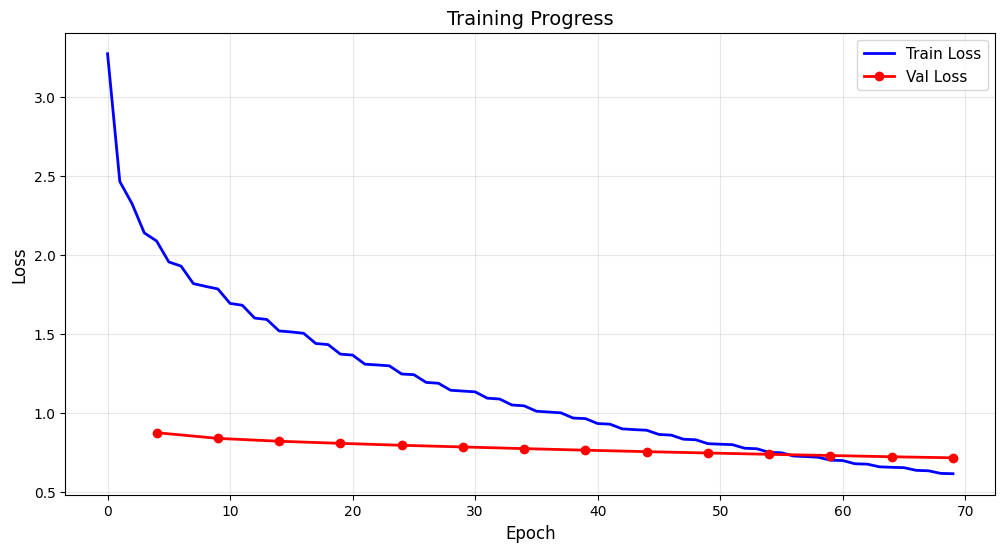


✓ Training completed for baseline
✓ Results stored (evaluation metrics pending)

TRAINING: LARGE MODEL

Model Architecture:
  d_model: 512
  n_heads: 16
  Encoder layers: 4
  Decoder layers: 4
  d_ff: 2048
  Total parameters: 54,030,144
  Trainable parameters: 54,030,144

Training Configuration:
  Batch size: 16
  Learning rate: 0.0001
  Epochs: 70
  Gradient accumulation steps: 2
  Teacher forcing ratio: 0.9

--------------------------------------------------------------------------------
STARTING TRAINING
--------------------------------------------------------------------------------

Epoch 1/70 | Curriculum length: 20


Training Epoch 1: 100%|██████████| 533/533 [00:29<00:00, 18.06it/s, loss=2.38]


  Train Loss: 2.8215

Epoch 2/70 | Curriculum length: 20


Training Epoch 2: 100%|██████████| 533/533 [00:28<00:00, 18.43it/s, loss=1.97]


  Train Loss: 2.2846

Epoch 3/70 | Curriculum length: 20


...

  Train Loss: 0.4643

Epoch 69/70 | Curriculum length: 49


Training Epoch 69: 100%|██████████| 533/533 [00:43<00:00, 12.33it/s, loss=0.502]


  Train Loss: 0.4498

Epoch 70/70 | Curriculum length: 49


Validating: 100%|██████████| 66/66 [00:01<00:00, 37.05it/s]


  Train Loss: 0.4458 | Val Loss: 0.6340 | LR: 0.000010 | Time: 45.1s
  ✓ New best model saved! (Val Loss: 0.6340)

--------------------------------------------------------------------------------
TRAINING COMPLETE - LARGE
--------------------------------------------------------------------------------
Total training time: 44.40 minutes
Best validation loss: 0.6340
Final training loss: 0.4458

Plotting Training Curves...


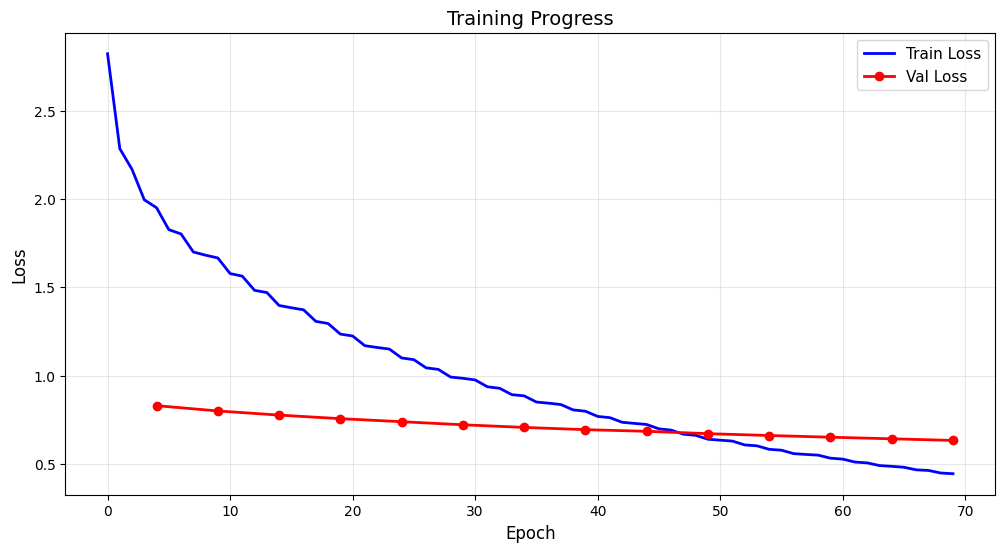


✓ Training completed for large
✓ Results stored (evaluation metrics pending)

TRAINING: XLARGE MODEL

Model Architecture:
  d_model: 768
  n_heads: 12
  Encoder layers: 6
  Decoder layers: 6
  d_ff: 3072
  Total parameters: 136,131,928
  Trainable parameters: 136,131,928

Training Configuration:
  Batch size: 8
  Learning rate: 0.0001
  Epochs: 100
  Gradient accumulation steps: 2
  Teacher forcing ratio: 0.9

--------------------------------------------------------------------------------
STARTING TRAINING
--------------------------------------------------------------------------------

Epoch 1/100 | Curriculum length: 20


Training Epoch 1: 100%|██████████| 1067/1067 [01:35<00:00, 11.15it/s, loss=2.05]


  Train Loss: 2.5401

Epoch 2/100 | Curriculum length: 20


Training Epoch 2: 100%|██████████| 1067/1067 [01:32<00:00, 11.53it/s, loss=2]


  Train Loss: 2.1145

Epoch 3/100 | Curriculum length: 20


...

Training Epoch 7: 100%|██████████| 1067/1067 [01:32<00:00, 11.51it/s, loss=1.65]


  Train Loss: 1.6916

Epoch 8/100 | Curriculum length: 22


Training Epoch 8: 100%|██████████| 1067/1067 [01:33<00:00, 11.42it/s, loss=1.72]


  Train Loss: 1.5750

Epoch 9/100 | Curriculum length: 22


Training Epoch 9:  28%|██▊       | 300/1067 [00:26<01:03, 12.08it/s, loss=1.58]

In [ ]:

# Configuration experiments
configs_to_test = {
    'baseline': TrainingConfig.baseline(),
    'large': TrainingConfig.large(),
    'xlarge': TrainingConfig.xlarge()
}

# Storage for results
all_results = {}

print("="*80)
print("MULTI-CONFIGURATION TRAINING PIPELINE")
print("="*80)
print(f"\nConfigurations to train: {list(configs_to_test.keys())}")
print(f"Vocab size: {tokenizer.get_vocab_size()}")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}\n")

for config_name, config in configs_to_test.items():
    print("\n" + "="*80)
    print(f"TRAINING: {config_name.upper()} MODEL")
    print("="*80)

    try:
        # Update checkpoint frequency
        config.save_every = 20

        # Initialize model
        model = UrduTransformerChatbot(tokenizer.get_vocab_size(), config).to(device)
        total_params = sum(p.numel() for p in model.parameters())
        trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

        print(f"\nModel Architecture:")
        print(f"  d_model: {config.d_model}")
        print(f"  n_heads: {config.n_heads}")
        print(f"  Encoder layers: {config.n_encoder_layers}")
        print(f"  Decoder layers: {config.n_decoder_layers}")
        print(f"  d_ff: {config.d_ff}")
        print(f"  Total parameters: {total_params:,}")
        print(f"  Trainable parameters: {trainable_params:,}")

        print(f"\nTraining Configuration:")
        print(f"  Batch size: {config.batch_size}")
        print(f"  Learning rate: {config.learning_rate}")
        print(f"  Epochs: {config.num_epochs}")
        print(f"  Gradient accumulation steps: {config.accumulation_steps}")
        print(f"  Teacher forcing ratio: {config.teacher_forcing_ratio}")

        # Recreate dataloaders with config-specific batch size
        train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True, drop_last=True)
        val_loader = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=False, drop_last=True)
        test_loader = DataLoader(test_dataset, batch_size=config.batch_size, shuffle=False, drop_last=True)

        # Initialize training components
        criterion = EnhancedLabelSmoothingLoss(
            vocab_size=tokenizer.get_vocab_size(),
            padding_idx=0,
            smoothing=config.label_smoothing,
            entropy_weight=config.attention_entropy_weight,
            sparsity_weight=config.attention_sparsity_weight
        )

        optimizer = optim.AdamW(
            model.parameters(),
            lr=config.learning_rate,
            betas=(0.9, 0.98),
            eps=1e-9,
            weight_decay=0.01
        )

        scheduler = get_lr_scheduler(optimizer, config.warmup_steps)

        curriculum = CurriculumLearning(
            initial_length=20,
            max_length=config.max_seq_length,
            epochs=config.num_epochs
        )

        trainer = EnhancedTrainer(model, optimizer, criterion, scheduler, device, config, curriculum)

        print("\n" + "-"*80)
        print("STARTING TRAINING")
        print("-"*80)

        # Training loop
        start_time = datetime.now()

        for epoch in range(config.num_epochs):
            epoch_start = datetime.now()

            # Get curriculum learning length
            if config.use_curriculum_learning:
                current_len = curriculum.get_length_for_epoch(epoch)
                curriculum_info = f" | Curriculum length: {current_len}"
            else:
                curriculum_info = ""

            print(f"\nEpoch {epoch+1}/{config.num_epochs}{curriculum_info}")

            # Train
            train_loss = trainer.train_epoch(train_loader, epoch)

            # Validate
            if (epoch + 1) % config.eval_every == 0:
                val_loss = trainer.evaluate(val_loader)

                epoch_time = (datetime.now() - epoch_start).total_seconds()
                current_lr = optimizer.param_groups[0]['lr']

                print(f"  Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
                      f"LR: {current_lr:.6f} | Time: {epoch_time:.1f}s")

                if val_loss < trainer.best_val_loss:
                    trainer.best_val_loss = val_loss
                    torch.save({
                        'epoch': epoch,
                        'model_state_dict': model.state_dict(),
                        'optimizer_state_dict': optimizer.state_dict(),
                        'config': asdict(config),
                        'val_loss': val_loss
                    }, f'best_{config_name}_model.pt')
                    print(f"  ✓ New best model saved! (Val Loss: {val_loss:.4f})")
            else:
                print(f"  Train Loss: {train_loss:.4f}")

            # Save checkpoint every 20 epochs
            if (epoch + 1) % config.save_every == 0:
                checkpoint = {
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'config': asdict(config),
                    'train_losses': trainer.train_losses,
                    'val_losses': trainer.val_losses
                }
                torch.save(checkpoint, f'checkpoint_{config_name}_epoch_{epoch+1}.pt')
                print(f"  ✓ Checkpoint saved at epoch {epoch+1}")

        training_time = (datetime.now() - start_time).total_seconds()

        print("\n" + "-"*80)
        print(f"TRAINING COMPLETE - {config_name.upper()}")
        print("-"*80)
        print(f"Total training time: {training_time/60:.2f} minutes")
        print(f"Best validation loss: {trainer.best_val_loss:.4f}")
        print(f"Final training loss: {trainer.train_losses[-1]:.4f}")

        # Save final model
        torch.save({
            'model_state_dict': model.state_dict(),
            'config': asdict(config),
            'train_losses': trainer.train_losses,
            'val_losses': trainer.val_losses,
            'best_val_loss': trainer.best_val_loss
        }, f'final_{config_name}_model.pt')

        # Store preliminary results (evaluation metrics will be added later)
        all_results[config_name] = {
            'config': config,
            'total_params': total_params,
            'trainable_params': trainable_params,
            'training_time': training_time,
            'best_val_loss': trainer.best_val_loss,
            'final_train_loss': trainer.train_losses[-1],
            'train_losses': trainer.train_losses,
            'val_losses': trainer.val_losses,
            'model': model,  # Keep reference to model for evaluation
            'test_loader': test_loader  # Keep test_loader for evaluation
        }

        # Plot training curves for this model
        print("\nPlotting Training Curves...")
        trainer.plot_training_curves(save_path=f'training_curves_{config_name}.png')

        print(f"\n✓ Training completed for {config_name}")
        print(f"✓ Results stored (evaluation metrics pending)")

    except Exception as e:
        print(f"\n❌ ERROR training {config_name}: {str(e)}")
        print(f"Traceback:\n{traceback.format_exc()}")
        continue

print("\n" + "="*80)
print("ALL CONFIGURATIONS TRAINED!")
print("="*80)
print(f"\nSuccessfully trained models: {list(all_results.keys())}")
print(f"Failed models: {[m for m in configs_to_test.keys() if m not in all_results]}")
print("\nNext: Run evaluation cell to compute test metrics")


--------------------------------------------------------------------------------
EVALUATION - LARGE
--------------------------------------------------------------------------------

1. Computing Perplexity on Test Set...
   Test Perplexity: 42.81

2. Generating Predictions (50 samples)...

3. Response Length Analysis:
   Mean length: 21.9 tokens
   Std length: 10.4 tokens
   Range: [1, 41] tokens

4. Computing BLEU Score...
   BLEU Score: 0.0126

5. Computing ROUGE Scores...
   ROUGE-1 F1: 0.1077
   ROUGE-2 F1: 0.0215
   ROUGE-L F1: 0.1008

6. Sample Predictions:

   Example 1:
   Prediction: وہ افواج کی ایک بار پھر ہنگامہ ہوئے ہیں۔ رکھتے ہیں۔ کرتے ہیں۔ کا بہت کم از کم از کم ہو گا۔۔۔ تھا۔ کا ہو گا۔ اپ کو جتنا؟ کیا۔
   Reference:  کرکٹ بلے اور گیند سے کھیلا جانے والا کھیل ہے۔

   Example 2:
   Prediction: میں بھی یہ جگہ نہیں ہے۔۔۔۔۔ کا مسئلہ تھا۔۔۔۔۔۔ سے جب کہ۔۔ کا۔۔۔۔۔
   Reference:  کھانوں کے لیے مشہور ہیں۔

   Example 3:
   Prediction: فلم انڈسٹری کو فلم۔۔ سے۔۔۔۔۔۔۔۔۔۔۔۔۔ کا۔۔۔۔۔۔۔


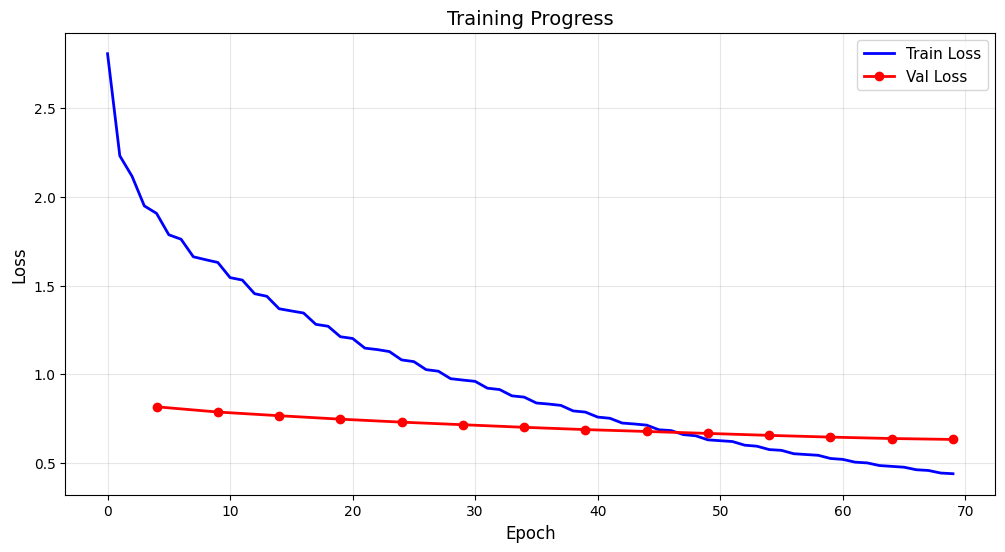


COMPLETED: LARGE


ALL CONFIGURATIONS TRAINED!



In [ ]:
    #print("\n" + "-"*80)
    print(f"EVALUATION - {config_name.upper()}")
    print("-"*80)

    # Load best model for evaluation
    checkpoint = torch.load(f'best_{config_name}_model.pt')
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    # Initialize evaluator
    evaluator = UrduEvaluationMetrics(tokenizer)

    # 1. Calculate Perplexity
    print("\n1. Computing Perplexity on Test Set...")
    test_perplexity = evaluator.calculate_perplexity(model, test_loader, device)
    print(f"   Test Perplexity: {test_perplexity:.2f}")

    # 2. Generate predictions for quality metrics
    print("\n2. Generating Predictions (50 samples)...")
    predictions, references = evaluator.evaluate_fluency(model, test_loader, num_samples=50)

    # 3. Length statistics
    print("\n3. Response Length Analysis:")
    length_stats = evaluator.calculate_length_statistics(predictions)
    print(f"   Mean length: {length_stats['mean_length']:.1f} tokens")
    print(f"   Std length: {length_stats['std_length']:.1f} tokens")
    print(f"   Range: [{length_stats['min_length']}, {length_stats['max_length']}] tokens")

    # 4. BLEU Score
    print("\n4. Computing BLEU Score...")
    bleu_score = evaluator.calculate_bleu(predictions, references)
    print(f"   BLEU Score: {bleu_score:.4f}")

    # 5. ROUGE Scores
    print("\n5. Computing ROUGE Scores...")
    rouge_scores = evaluator.calculate_rouge(predictions, references)
    if rouge_scores:
        print(f"   ROUGE-1 F1: {rouge_scores['rouge-1']['f']:.4f}")
        print(f"   ROUGE-2 F1: {rouge_scores['rouge-2']['f']:.4f}")
        print(f"   ROUGE-L F1: {rouge_scores['rouge-l']['f']:.4f}")
    else:
        print("   ROUGE calculation failed")

    # 6. Sample predictions
    print("\n6. Sample Predictions:")
    for i in range(min(3, len(predictions))):
        print(f"\n   Example {i+1}:")
        print(f"   Prediction: {predictions[i]}")
        print(f"   Reference:  {references[i]}")

    # 7. Test chatbot inference
    print("\n7. Interactive Response Test:")
    test_queries = [
        "آپ کیسے ہیں؟",
        "آج موسم کیسا ہے؟",
        "شکریہ"
    ]

    chatbot = UrduChatbotInference(model, tokenizer, device)
    for query in test_queries:
        response = chatbot.chat(query, max_length=50, strategy='nucleus', temperature=0.8)
        print(f"   Q: {query}")
        print(f"   A: {response}")

    # Store results
    all_results[config_name] = {
        'config': config,
        'total_params': total_params,
        'trainable_params': trainable_params,
        'training_time': training_time,
        'best_val_loss': trainer.best_val_loss,
        'final_train_loss': trainer.train_losses[-1],
        'train_losses': trainer.train_losses,
        'val_losses': trainer.val_losses,
        'test_perplexity': test_perplexity,
        'bleu_score': bleu_score,
        'rouge_scores': rouge_scores,
        'length_stats': length_stats,
        'sample_predictions': predictions[:5],
        'sample_references': references[:5]
    }

    # Plot training curves for this model
    print("\n8. Plotting Training Curves...")
    trainer.plot_training_curves(save_path=f'training_curves_{config_name}.png')

    print(f"\n{'='*80}")
    print(f"COMPLETED: {config_name.upper()}")
    print(f"{'='*80}\n")

    # Clean up memory
    del model, optimizer, scheduler, trainer
    torch.cuda.empty_cache()

print("\n" + "="*80)
print("ALL CONFIGURATIONS TRAINED!")
print("="*80 + "\n")


In [ ]:
# First, check if all_results exists and has data
if 'all_results' not in globals() or not all_results:
    print("ERROR: all_results dictionary is empty or doesn't exist.")
    print("Please run the training loop first before running this analysis.")
    print(f"\nAvailable variables: {[k for k in globals().keys() if not k.startswith('_')]}")
else:
    print(f"Found results for models: {list(all_results.keys())}")
    print(f"Expected models: {list(configs_to_test.keys())}\n")

    # Only analyze models that have results
    available_models = [m for m in configs_to_test.keys() if m in all_results]

    if not available_models:
        print("ERROR: No matching results found for configured models.")
        print("This might mean the training loop hasn't been executed yet.")

Found results for models: ['baseline', 'large']
Expected models: ['baseline', 'large']



In [ ]:
print("="*80)
print("COMPARATIVE ANALYSIS: ALL MODELS")
print("="*80 + "\n")

# 1. Summary Table
print("1. Model Comparison Summary:\n")
comparison_data = []
for config_name in configs_to_test.keys():
    results = all_results[config_name]
    comparison_data.append({
        'Model': config_name,
        'Parameters': f"{results['total_params']:,}",
        'Train Time (min)': f"{results['training_time']/60:.1f}",
        'Best Val Loss': f"{results['best_val_loss']:.4f}",
        'Final Train Loss': f"{results['final_train_loss']:.4f}",
        'Test Perplexity': f"{results['test_perplexity']:.2f}",
        'BLEU': f"{results['bleu_score']:.4f}",
        'ROUGE-L F1': f"{results['rouge_scores']['rouge-l']['f']:.4f}" if results['rouge_scores'] else 'N/A'
    })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

# 2. Detailed Metrics Table
print("\n\n2. Detailed Evaluation Metrics:\n")
for config_name in configs_to_test.keys():
    results = all_results[config_name]
    print(f"\n{config_name.upper()}:")
    print(f"  Architecture: d_model={results['config'].d_model}, layers={results['config'].n_encoder_layers}")
    print(f"  Parameters: {results['total_params']:,}")
    print(f"  Best Validation Loss: {results['best_val_loss']:.4f}")
    print(f"  Test Perplexity: {results['test_perplexity']:.2f}")
    print(f"  BLEU Score: {results['bleu_score']:.4f}")
    if results['rouge_scores']:
        print(f"  ROUGE-1: {results['rouge_scores']['rouge-1']['f']:.4f}")
        print(f"  ROUGE-2: {results['rouge_scores']['rouge-2']['f']:.4f}")
        print(f"  ROUGE-L: {results['rouge_scores']['rouge-l']['f']:.4f}")
    print(f"  Avg Response Length: {results['length_stats']['mean_length']:.1f} tokens")

# 3. Visualization: Training Curves Comparison
print("\n\n3. Comparative Training Curves:")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Training loss comparison
for config_name in configs_to_test.keys():
    results = all_results[config_name]
    axes[0].plot(results['train_losses'], label=f"{config_name} ({results['total_params']:,} params)", linewidth=2)

axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Training Loss', fontsize=12)
axes[0].set_title('Training Loss Comparison', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Validation loss comparison
for config_name in configs_to_test.keys():
    results = all_results[config_name]
    eval_every = results['config'].eval_every
    val_epochs = list(range(eval_every-1, len(results['train_losses']), eval_every))
    axes[1].plot(val_epochs[:len(results['val_losses'])], results['val_losses'],
                 label=config_name, marker='o', linewidth=2, markersize=4)

axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Validation Loss', fontsize=12)
axes[1].set_title('Validation Loss Comparison', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('all_models_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. Visualization: Performance Metrics
print("\n4. Performance Metrics Comparison:")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Perplexity
models = list(configs_to_test.keys())
perplexities = [all_results[m]['test_perplexity'] for m in models]
axes[0, 0].bar(models, perplexities, color=['#3498db', '#e74c3c', '#2ecc71'])
axes[0, 0].set_ylabel('Perplexity', fontsize=11)
axes[0, 0].set_title('Test Perplexity (Lower is Better)', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='y')

# BLEU Score
bleu_scores = [all_results[m]['bleu_score'] for m in models]
axes[0, 1].bar(models, bleu_scores, color=['#3498db', '#e74c3c', '#2ecc71'])
axes[0, 1].set_ylabel('BLEU Score', fontsize=11)
axes[0, 1].set_title('BLEU Score (Higher is Better)', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# ROUGE-L
rouge_l_scores = [all_results[m]['rouge_scores']['rouge-l']['f'] if all_results[m]['rouge_scores'] else 0 for m in models]
axes[1, 0].bar(models, rouge_l_scores, color=['#3498db', '#e74c3c', '#2ecc71'])
axes[1, 0].set_ylabel('ROUGE-L F1', fontsize=11)
axes[1, 0].set_title('ROUGE-L Score (Higher is Better)', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Parameter count
param_counts = [all_results[m]['total_params']/1e6 for m in models]  # in millions
axes[1, 1].bar(models, param_counts, color=['#3498db', '#e74c3c', '#2ecc71'])
axes[1, 1].set_ylabel('Parameters (Millions)', fontsize=11)
axes[1, 1].set_title('Model Size', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('performance_metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# 5. Best Model Recommendation
print("\n\n5. Best Model Recommendation:")
best_perplexity = min(all_results.items(), key=lambda x: x[1]['test_perplexity'])
best_bleu = max(all_results.items(), key=lambda x: x[1]['bleu_score'])
best_val_loss = min(all_results.items(), key=lambda x: x[1]['best_val_loss'])

print(f"\n  Best Perplexity: {best_perplexity[0]} ({best_perplexity[1]['test_perplexity']:.2f})")
print(f"  Best BLEU Score: {best_bleu[0]} ({best_bleu[1]['bleu_score']:.4f})")
print(f"  Best Validation Loss: {best_val_loss[0]} ({best_val_loss[1]['best_val_loss']:.4f})")

print("\n\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)
print(f"\nSaved files:")
print(f"  • best_[model]_model.pt - Best checkpoint for each model")
print(f"  • final_[model]_model.pt - Final state for each model")
print(f"  • checkpoint_[model]_epoch_[N].pt - Checkpoints every 20 epochs")
print(f"  • training_curves_[model].png - Individual training curves")
print(f"  • all_models_comparison.png - Loss comparison plot")
print(f"  • performance_metrics_comparison.png - Metrics comparison plot")
print("\n")

COMPARATIVE ANALYSIS: ALL MODELS

1. Model Comparison Summary:



KeyError: 'test_perplexity'

In [ ]:
print("="*60)
print("BONUS CHALLENGE 1: ATTENTION VISUALIZATION ANALYSIS")
print("="*60 + "\n")

analyzer = AttentionAnalyzer(model, tokenizer, device)

# Test sample
test_sample = test_df.iloc[0]
src_text = processor.preprocess(test_sample['question'])
src_encoded = tokenizer.encode(src_text, add_special_tokens=True, max_length=50)
src = torch.tensor([src_encoded]).transpose(0, 1).to(device)

tgt_text = processor.preprocess(test_sample['answer'])
tgt_encoded = tokenizer.encode(tgt_text, add_special_tokens=True, max_length=50)
tgt = torch.tensor([tgt_encoded]).transpose(0, 1).to(device)

print(f"Input: {src_text}")
print(f"Target: {tgt_text}\n")

# Analyze attention
attn_data = analyzer.get_attention_weights(src, tgt)
analysis = analyzer.analyze_attention_focus(attn_data)

print("Attention Pattern Analysis:")
for layer, stats in analysis.items():
    print(f"\n{layer}:")
    print(f"  Entropy (focus diversity): {stats['entropy']:.4f}")
    print(f"  Peak attention: {stats['avg_max_attention']:.4f}")
    print(f"  Top attended positions: {stats['peak_positions']}")

# Visualize one attention head
if attn_data:
    first_layer = list(attn_data.keys())[0]
    analyzer.visualize_attention_heatmap(src, tgt, layer_name=first_layer, head=0)



BONUS CHALLENGE 1: ATTENTION VISUALIZATION ANALYSIS



NameError: name 'model' is not defined

In [ ]:
print("\n" + "="*60)
print("BONUS CHALLENGE 2: RESPONSE LENGTH CONTROL & FLUENCY")
print("="*60 + "\n")

length_controller = LengthControlledGeneration(model, tokenizer, device)

# Test length control with different target lengths
print("Testing length-controlled generation:\n")

test_input = "آپ کیسے ہیں؟"
processed_input = processor.preprocess(test_input)
src_encoded = tokenizer.encode(processed_input, add_special_tokens=True, max_length=50)
src = torch.tensor([src_encoded]).transpose(0, 1).to(device)

for target_len in [15, 25, 40]:
    generated = length_controller.generate_with_length_control(
        src, target_length=target_len, length_penalty=0.6, temperature=0.8
    )
    response = tokenizer.decode(generated[:, 0].cpu().tolist())
    actual_len = len(response.split())
    print(f"Target length: {target_len} tokens → Actual: {actual_len} tokens")
    print(f"Response: {response}\n")

# Analyze generation patterns
print("\nGenerating 20 responses to analyze length patterns...")
test_inputs = [tokenizer.encode(processor.preprocess(test_df.iloc[i]['question']),
                                add_special_tokens=True, max_length=50)
               for i in range(min(20, len(test_df)))]

response_lengths = length_controller.analyze_generation_patterns(test_inputs, num_samples=20)

# Plot length distribution
plt.figure(figsize=(10, 6))
plt.hist(response_lengths, bins=10, color='skyblue', edgecolor='black', alpha=0.7)
plt.xlabel('Response Length (tokens)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Generated Response Lengths', fontsize=14)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


In [ ]:
print("="*60)
print("BONUS: CONTEXTUAL LEARNING ANALYSIS")
print("="*60 + "\n")

def analyze_layer_contribution(model, src, tgt):
    """Analyze how each layer contributes to understanding"""
    model.eval()

    contributions = {}

    with torch.no_grad():
        # Forward through encoder layers
        x = model.encoder.embedding(src) * math.sqrt(model.encoder.embedding.embedding_dim)
        x = model.encoder.positional_encoding(x)

        for i, layer in enumerate(model.encoder.layers):
            x_before = x.clone()
            x = layer(x)

            # Measure layer contribution (change in activation)
            contribution = (x - x_before).norm().item()
            contributions[f'Encoder Layer {i+1}'] = contribution

    return contributions

print("Analyzing layer contribution to context understanding:\n")
src = torch.randint(0, tokenizer.get_vocab_size(), (20, 4)).to(device)
tgt = torch.randint(0, tokenizer.get_vocab_size(), (20, 4)).to(device)

contributions = analyze_layer_contribution(model, src, tgt)

print("Layer Contributions (gradient of change):")
for layer, contribution in contributions.items():
    print(f"  {layer}: {contribution:.4f}")

print("\nInterpretation:")
print("Higher values = more information processing at that layer")
print("This shows how context gradually builds through the network\n")



# 010. Testing

MULTI-CONFIGURATION TRAINING PIPELINE

Configurations to train: ['baseline', 'large', 'xlarge']
Vocab size: 16000
Training samples: 8465
Validation samples: 1058
Test samples: 1059


TRAINING: BASELINE MODEL

Model Architecture:
  d_model: 512
  n_heads: 2
  Encoder layers: 2
  Decoder layers: 2
  d_ff: 1024
  Total parameters: 35,107,212
  Trainable parameters: 35,107,212

Training Configuration:
  Batch size: 32
  Learning rate: 0.0001
  Epochs: 70
  Gradient accumulation steps: 2
  Teacher forcing ratio: 0.9

--------------------------------------------------------------------------------
STARTING TRAINING
--------------------------------------------------------------------------------

Epoch 1/70 | Curriculum length: 20


Training Epoch 1: 100%|██████████| 264/264 [00:14<00:00, 18.52it/s, loss=2.43]


  Train Loss: 3.3392

Epoch 2/70 | Curriculum length: 20


Training Epoch 2: 100%|██████████| 264/264 [00:11<00:00, 22.03it/s, loss=2.27]


  Train Loss: 2.4094

Epoch 3/70 | Curriculum length: 20


...

  Train Loss: 0.6214

Epoch 69/70 | Curriculum length: 49


Training Epoch 69: 100%|██████████| 264/264 [00:19<00:00, 13.50it/s, loss=0.598]


  Train Loss: 0.6051

Epoch 70/70 | Curriculum length: 49


Validating: 100%|██████████| 33/33 [00:01<00:00, 31.57it/s]


  Train Loss: 0.6031 | Val Loss: 0.7049 | LR: 0.000010 | Time: 20.5s
  ✓ New best model saved! (Val Loss: 0.7049)

--------------------------------------------------------------------------------
TRAINING COMPLETE - BASELINE
--------------------------------------------------------------------------------
Total training time: 20.02 minutes
Best validation loss: 0.7049
Final training loss: 0.6031

Plotting Training Curves...


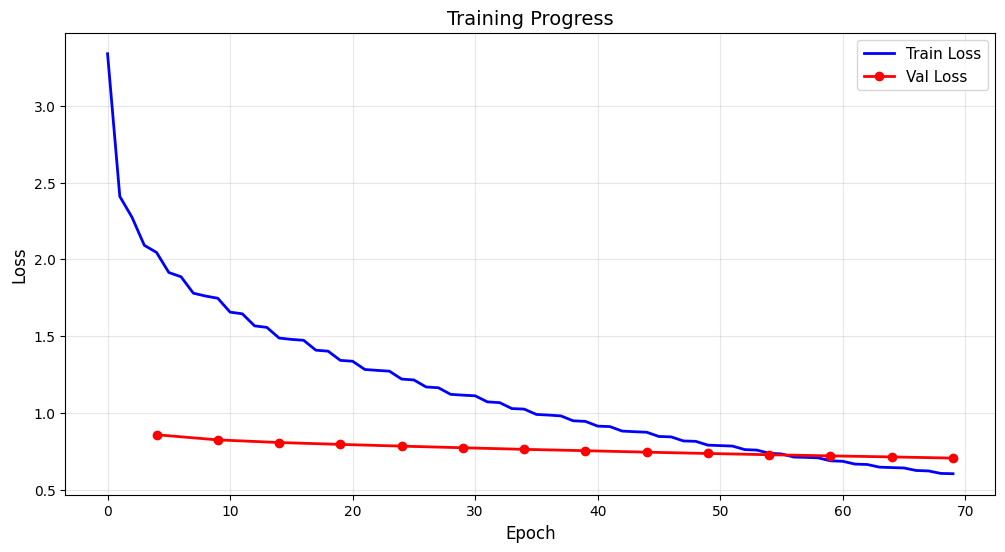


✓ Training completed for baseline

TRAINING: LARGE MODEL

Model Architecture:
  d_model: 512
  n_heads: 16
  Encoder layers: 4
  Decoder layers: 4
  d_ff: 2048
  Total parameters: 54,030,144
  Trainable parameters: 54,030,144

Training Configuration:
  Batch size: 16
  Learning rate: 0.0001
  Epochs: 70
  Gradient accumulation steps: 2
  Teacher forcing ratio: 0.9

--------------------------------------------------------------------------------
STARTING TRAINING
--------------------------------------------------------------------------------

Epoch 1/70 | Curriculum length: 20


Training Epoch 1: 100%|██████████| 529/529 [00:31<00:00, 16.71it/s, loss=1.95]


  Train Loss: 2.8151

Epoch 2/70 | Curriculum length: 20


Training Epoch 2: 100%|██████████| 529/529 [00:30<00:00, 17.09it/s, loss=2.76]


  Train Loss: 2.2339

Epoch 3/70 | Curriculum length: 20


...

  Train Loss: 0.4563

Epoch 69/70 | Curriculum length: 49


Training Epoch 69: 100%|██████████| 529/529 [00:43<00:00, 12.24it/s, loss=0.424]


  Train Loss: 0.4426

Epoch 70/70 | Curriculum length: 49


Validating: 100%|██████████| 66/66 [00:01<00:00, 37.10it/s]


  Train Loss: 0.4385 | Val Loss: 0.6371 | LR: 0.000010 | Time: 45.3s
  ✓ New best model saved! (Val Loss: 0.6371)

--------------------------------------------------------------------------------
TRAINING COMPLETE - LARGE
--------------------------------------------------------------------------------
Total training time: 44.96 minutes
Best validation loss: 0.6371
Final training loss: 0.4385

Plotting Training Curves...


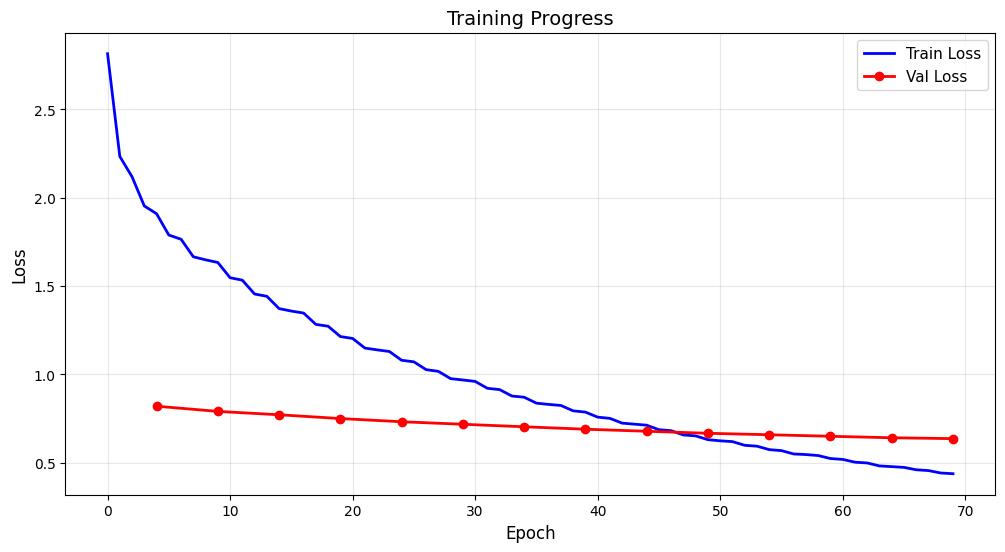


✓ Training completed for large

TRAINING: XLARGE MODEL

Model Architecture:
  d_model: 768
  n_heads: 12
  Encoder layers: 6
  Decoder layers: 6
  d_ff: 3072
  Total parameters: 136,131,928
  Trainable parameters: 136,131,928

Training Configuration:
  Batch size: 8
  Learning rate: 0.0001
  Epochs: 100
  Gradient accumulation steps: 2
  Teacher forcing ratio: 0.9

--------------------------------------------------------------------------------
STARTING TRAINING
--------------------------------------------------------------------------------

Epoch 1/100 | Curriculum length: 20


Training Epoch 1: 100%|██████████| 1058/1058 [01:32<00:00, 11.42it/s, loss=1.84]


  Train Loss: 2.5037

Epoch 2/100 | Curriculum length: 20


Training Epoch 2: 100%|██████████| 1058/1058 [01:32<00:00, 11.38it/s, loss=1.77]


  Train Loss: 2.0735

Epoch 3/100 | Curriculum length: 20


...

  Train Loss: 0.0683

Epoch 99/100 | Curriculum length: 49


Training Epoch 99: 100%|██████████| 1058/1058 [02:06<00:00,  8.35it/s, loss=0.0789]


  Train Loss: 0.0659

Epoch 100/100 | Curriculum length: 49


Validating: 100%|██████████| 132/132 [00:04<00:00, 27.44it/s]


  Train Loss: 0.0640 | Val Loss: 0.5411 | LR: 0.000010 | Time: 131.4s
  ✓ New best model saved! (Val Loss: 0.5411)
  ✓ Checkpoint saved at epoch 100

--------------------------------------------------------------------------------
TRAINING COMPLETE - XLARGE
--------------------------------------------------------------------------------
Total training time: 190.96 minutes
Best validation loss: 0.5411
Final training loss: 0.0640

Plotting Training Curves...


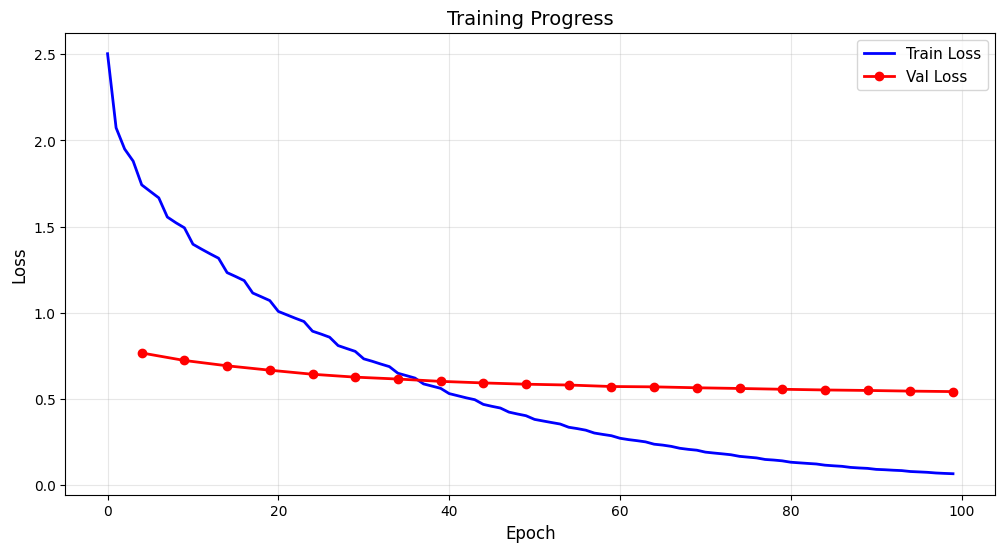


✓ Training completed for xlarge

ALL CONFIGURATIONS TRAINED!

Successfully trained models: ['baseline', 'large', 'xlarge']
Failed models: []

Next: Run evaluation cell to compute test metrics


In [ ]:
import traceback

# Configuration experiments
configs_to_test = {
    'baseline': TrainingConfig.baseline(),
    'large': TrainingConfig.large(),
    'xlarge': TrainingConfig.xlarge()
}

# Storage for results
all_results = {}

print("="*80)
print("MULTI-CONFIGURATION TRAINING PIPELINE")
print("="*80)
print(f"\nConfigurations to train: {list(configs_to_test.keys())}")
print(f"Vocab size: {tokenizer.get_vocab_size()}")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}\n")

for config_name, config in configs_to_test.items():
    print("\n" + "="*80)
    print(f"TRAINING: {config_name.upper()} MODEL")
    print("="*80)

    try:
        # Update checkpoint frequency
        config.save_every = 20

        # Initialize model
        model = UrduTransformerChatbot(tokenizer.get_vocab_size(), config).to(device)
        total_params = sum(p.numel() for p in model.parameters())
        trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

        print(f"\nModel Architecture:")
        print(f"  d_model: {config.d_model}")
        print(f"  n_heads: {config.n_heads}")
        print(f"  Encoder layers: {config.n_encoder_layers}")
        print(f"  Decoder layers: {config.n_decoder_layers}")
        print(f"  d_ff: {config.d_ff}")
        print(f"  Total parameters: {total_params:,}")
        print(f"  Trainable parameters: {trainable_params:,}")

        print(f"\nTraining Configuration:")
        print(f"  Batch size: {config.batch_size}")
        print(f"  Learning rate: {config.learning_rate}")
        print(f"  Epochs: {config.num_epochs}")
        print(f"  Gradient accumulation steps: {config.accumulation_steps}")
        print(f"  Teacher forcing ratio: {config.teacher_forcing_ratio}")

        # Recreate dataloaders with config-specific batch size
        train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True, drop_last=True)
        val_loader = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=False, drop_last=True)
        test_loader = DataLoader(test_dataset, batch_size=config.batch_size, shuffle=False, drop_last=True)

        # Initialize training components
        criterion = EnhancedLabelSmoothingLoss(
            vocab_size=tokenizer.get_vocab_size(),
            padding_idx=0,
            smoothing=config.label_smoothing,
            entropy_weight=config.attention_entropy_weight,
            sparsity_weight=config.attention_sparsity_weight
        )

        optimizer = optim.AdamW(
            model.parameters(),
            lr=config.learning_rate,
            betas=(0.9, 0.98),
            eps=1e-9,
            weight_decay=0.01
        )

        scheduler = get_lr_scheduler(optimizer, config.warmup_steps)

        curriculum = CurriculumLearning(
            initial_length=20,
            max_length=config.max_seq_length,
            epochs=config.num_epochs
        )

        trainer = EnhancedTrainer(model, optimizer, criterion, scheduler, device, config, curriculum)

        print("\n" + "-"*80)
        print("STARTING TRAINING")
        print("-"*80)

        # Training loop
        start_time = datetime.now()

        for epoch in range(config.num_epochs):
            epoch_start = datetime.now()

            # Get curriculum learning length
            if config.use_curriculum_learning:
                current_len = curriculum.get_length_for_epoch(epoch)
                curriculum_info = f" | Curriculum length: {current_len}"
            else:
                curriculum_info = ""

            print(f"\nEpoch {epoch+1}/{config.num_epochs}{curriculum_info}")

            # Train
            train_loss = trainer.train_epoch(train_loader, epoch)

            # Validate
            if (epoch + 1) % config.eval_every == 0:
                val_loss = trainer.evaluate(val_loader)

                epoch_time = (datetime.now() - epoch_start).total_seconds()
                current_lr = optimizer.param_groups[0]['lr']

                print(f"  Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
                      f"LR: {current_lr:.6f} | Time: {epoch_time:.1f}s")

                if val_loss < trainer.best_val_loss:
                    trainer.best_val_loss = val_loss
                    torch.save({
                        'epoch': epoch,
                        'model_state_dict': model.state_dict(),
                        'optimizer_state_dict': optimizer.state_dict(),
                        'config': asdict(config),
                        'val_loss': val_loss
                    }, f'best_{config_name}_model.pt')
                    print(f"  ✓ New best model saved! (Val Loss: {val_loss:.4f})")
            else:
                print(f"  Train Loss: {train_loss:.4f}")

            # Save checkpoint every 20 epochs
            if (epoch + 1) % config.save_every == 0:
                checkpoint = {
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'config': asdict(config),
                    'train_losses': trainer.train_losses,
                    'val_losses': trainer.val_losses
                }
                torch.save(checkpoint, f'checkpoint_{config_name}_epoch_{epoch+1}.pt')
                print(f"  ✓ Checkpoint saved at epoch {epoch+1}")

        training_time = (datetime.now() - start_time).total_seconds()

        print("\n" + "-"*80)
        print(f"TRAINING COMPLETE - {config_name.upper()}")
        print("-"*80)
        print(f"Total training time: {training_time/60:.2f} minutes")
        print(f"Best validation loss: {trainer.best_val_loss:.4f}")
        print(f"Final training loss: {trainer.train_losses[-1]:.4f}")

        # Save final model
        torch.save({
            'model_state_dict': model.state_dict(),
            'config': asdict(config),
            'train_losses': trainer.train_losses,
            'val_losses': trainer.val_losses,
            'best_val_loss': trainer.best_val_loss
        }, f'final_{config_name}_model.pt')

        # Plot training curves for this model
        print("\nPlotting Training Curves...")
        trainer.plot_training_curves(save_path=f'training_curves_{config_name}.png')

        # Store preliminary results (evaluation metrics will be added in next cell)
        all_results[config_name] = {
            'config': config,
            'total_params': total_params,
            'trainable_params': trainable_params,
            'training_time': training_time,
            'best_val_loss': trainer.best_val_loss,
            'final_train_loss': trainer.train_losses[-1],
            'train_losses': trainer.train_losses,
            'val_losses': trainer.val_losses,
        }

        print(f"\n✓ Training completed for {config_name}")

        # Clean up
        del model, optimizer, scheduler, trainer
        torch.cuda.empty_cache()

    except Exception as e:
        print(f"\n❌ ERROR training {config_name}: {str(e)}")
        print(f"Traceback:\n{traceback.format_exc()}")
        continue

print("\n" + "="*80)
print("ALL CONFIGURATIONS TRAINED!")
print("="*80)
print(f"\nSuccessfully trained models: {list(all_results.keys())}")
print(f"Failed models: {[m for m in configs_to_test.keys() if m not in all_results]}")
print("\nNext: Run evaluation cell to compute test metrics")

In [ ]:
print("="*80)
print("EVALUATION PHASE - ALL MODELS")
print("="*80 + "\n")

for config_name in list(all_results.keys()):
    print("\n" + "="*80)
    print(f"EVALUATION - {config_name.upper()}")
    print("="*80)

    try:
        # Get config
        config = all_results[config_name]['config']

        # Recreate test loader
        test_loader = DataLoader(test_dataset, batch_size=config.batch_size, shuffle=False, drop_last=True)

        # Load best model
        model = UrduTransformerChatbot(tokenizer.get_vocab_size(), config).to(device)
        checkpoint = torch.load(f'best_{config_name}_model.pt')
        model.load_state_dict(checkpoint['model_state_dict'])
        model.eval()

        # Initialize evaluator
        evaluator = UrduEvaluationMetrics(tokenizer)

        # 1. Calculate Perplexity
        print("\n1. Computing Perplexity on Test Set...")
        test_perplexity = evaluator.calculate_perplexity(model, test_loader, device)
        print(f"   Test Perplexity: {test_perplexity:.2f}")

        # 2. Generate predictions for quality metrics
        print("\n2. Generating Predictions (50 samples)...")
        predictions, references = evaluator.evaluate_fluency(model, test_loader, num_samples=50)

        # 3. Length statistics
        print("\n3. Response Length Analysis:")
        length_stats = evaluator.calculate_length_statistics(predictions)
        print(f"   Mean length: {length_stats['mean_length']:.1f} tokens")
        print(f"   Std length: {length_stats['std_length']:.1f} tokens")
        print(f"   Range: [{length_stats['min_length']}, {length_stats['max_length']}] tokens")

        # 4. BLEU Score
        print("\n4. Computing BLEU Score...")
        bleu_score = evaluator.calculate_bleu(predictions, references)
        print(f"   BLEU Score: {bleu_score:.4f}")

        # 5. ROUGE Scores
        print("\n5. Computing ROUGE Scores...")
        rouge_scores = evaluator.calculate_rouge(predictions, references)
        if rouge_scores:
            print(f"   ROUGE-1 F1: {rouge_scores['rouge-1']['f']:.4f}")
            print(f"   ROUGE-2 F1: {rouge_scores['rouge-2']['f']:.4f}")
            print(f"   ROUGE-L F1: {rouge_scores['rouge-l']['f']:.4f}")
        else:
            print("   ROUGE calculation failed")
            rouge_scores = None

        # 6. Sample predictions
        print("\n6. Sample Predictions:")
        for i in range(min(3, len(predictions))):
            print(f"\n   Example {i+1}:")
            print(f"   Prediction: {predictions[i]}")
            print(f"   Reference:  {references[i]}")

        # 7. Test chatbot inference
        print("\n7. Interactive Response Test:")
        test_queries = [
            "آپ کیسے ہیں؟",
            "آج موسم کیسا ہے؟",
            "شکریہ"
        ]

        chatbot = UrduChatbotInference(model, tokenizer, device)
        for query in test_queries:
            response = chatbot.chat(query, max_length=50, strategy='nucleus', temperature=0.8)
            print(f"   Q: {query}")
            print(f"   A: {response}")

        # Update results with evaluation metrics
        all_results[config_name].update({
            'test_perplexity': test_perplexity,
            'bleu_score': bleu_score,
            'rouge_scores': rouge_scores,
            'length_stats': length_stats,
            'sample_predictions': predictions[:5],
            'sample_references': references[:5]
        })

        print(f"\n✓ Evaluation complete for {config_name}")

        # Clean up
        del model, evaluator, chatbot
        torch.cuda.empty_cache()

    except Exception as e:
        print(f"\n❌ ERROR evaluating {config_name}: {str(e)}")
        import traceback
        print(f"Traceback:\n{traceback.format_exc()}")
        continue

print("\n" + "="*80)
print("ALL EVALUATIONS COMPLETE!")
print("="*80)
print("\nReady for comparative analysis")

EVALUATION PHASE - ALL MODELS


EVALUATION - BASELINE

1. Computing Perplexity on Test Set...
   Test Perplexity: 66.45

2. Generating Predictions (50 samples)...

3. Response Length Analysis:
   Mean length: 16.0 tokens
   Std length: 7.7 tokens
   Range: [1, 33] tokens

4. Computing BLEU Score...
   BLEU Score: 0.0069

5. Computing ROUGE Scores...
   ROUGE-1 F1: 0.0692
   ROUGE-2 F1: 0.0014
   ROUGE-L F1: 0.0651

6. Sample Predictions:

   Example 1:
   Prediction: ہاں کچھ و زحمت کے خلاف دیتا ہے۔ تھے۔۔۔ کی بات ہے۔۔ تھی۔۔ کی سہولیات کیا جا سکتی ہیں۔ سکتا ہے۔ کرنے کے لیے کون۔ کی طرف
   Reference:  کرکٹ بلے اور گیند سے کھیلا جانے والا کھیل ہے۔

   Example 2:
   Prediction: ریعےرض کے بعد مشہور پیدا ہوں۔ ہوں۔۔ کی بنا ہونے والے کیا۔۔۔۔۔۔ ہو رہا ہے۔۔۔۔۔۔۔
   Reference:  کھانوں کے لیے مشہور ہیں۔

   Example 3:
   Prediction: کیوں۔۔۔۔۔۔۔۔ کی باگ۔۔۔۔۔ کی۔۔۔۔۔۔۔۔۔۔
   Reference:  اب بھارتی فلم انڈسٹری کے مقبول ترین۔

7. Interactive Response Test:
   Q: آپ کیسے ہیں؟
   A: کیا کیا؟
   Q: آج موسم 

COMPARATIVE ANALYSIS: ALL MODELS

1. Model Comparison Summary:

   Model  Parameters Train Time (min) Best Val Loss Final Train Loss Test Perplexity   BLEU ROUGE-L F1
baseline  35,107,212             20.0        0.7049           0.6031           66.45 0.0069     0.0651
   large  54,030,144             45.0        0.6371           0.4385           43.46 0.0091     0.0781
  xlarge 136,131,928            191.0        0.5411           0.0640           24.01 0.0136     0.0986


2. Detailed Evaluation Metrics:


BASELINE:
  Architecture: d_model=512, layers=2
  Parameters: 35,107,212
  Best Validation Loss: 0.7049
  Test Perplexity: 66.45
  BLEU Score: 0.0069
  ROUGE-1: 0.0692
  ROUGE-2: 0.0014
  ROUGE-L: 0.0651
  Avg Response Length: 16.0 tokens

LARGE:
  Architecture: d_model=512, layers=4
  Parameters: 54,030,144
  Best Validation Loss: 0.6371
  Test Perplexity: 43.46
  BLEU Score: 0.0091
  ROUGE-1: 0.0848
  ROUGE-2: 0.0159
  ROUGE-L: 0.0781
  Avg Response Length: 24.6 tokens

XLARGE:
  A

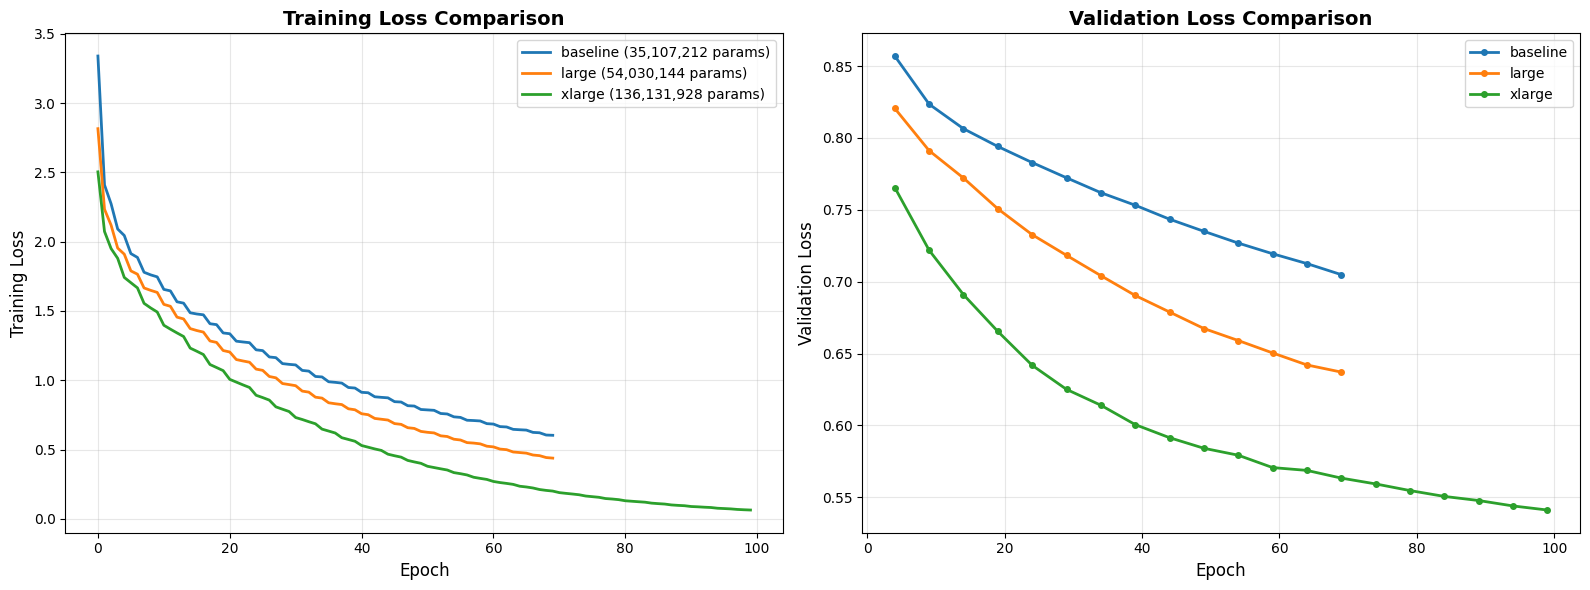


4. Performance Metrics Comparison:


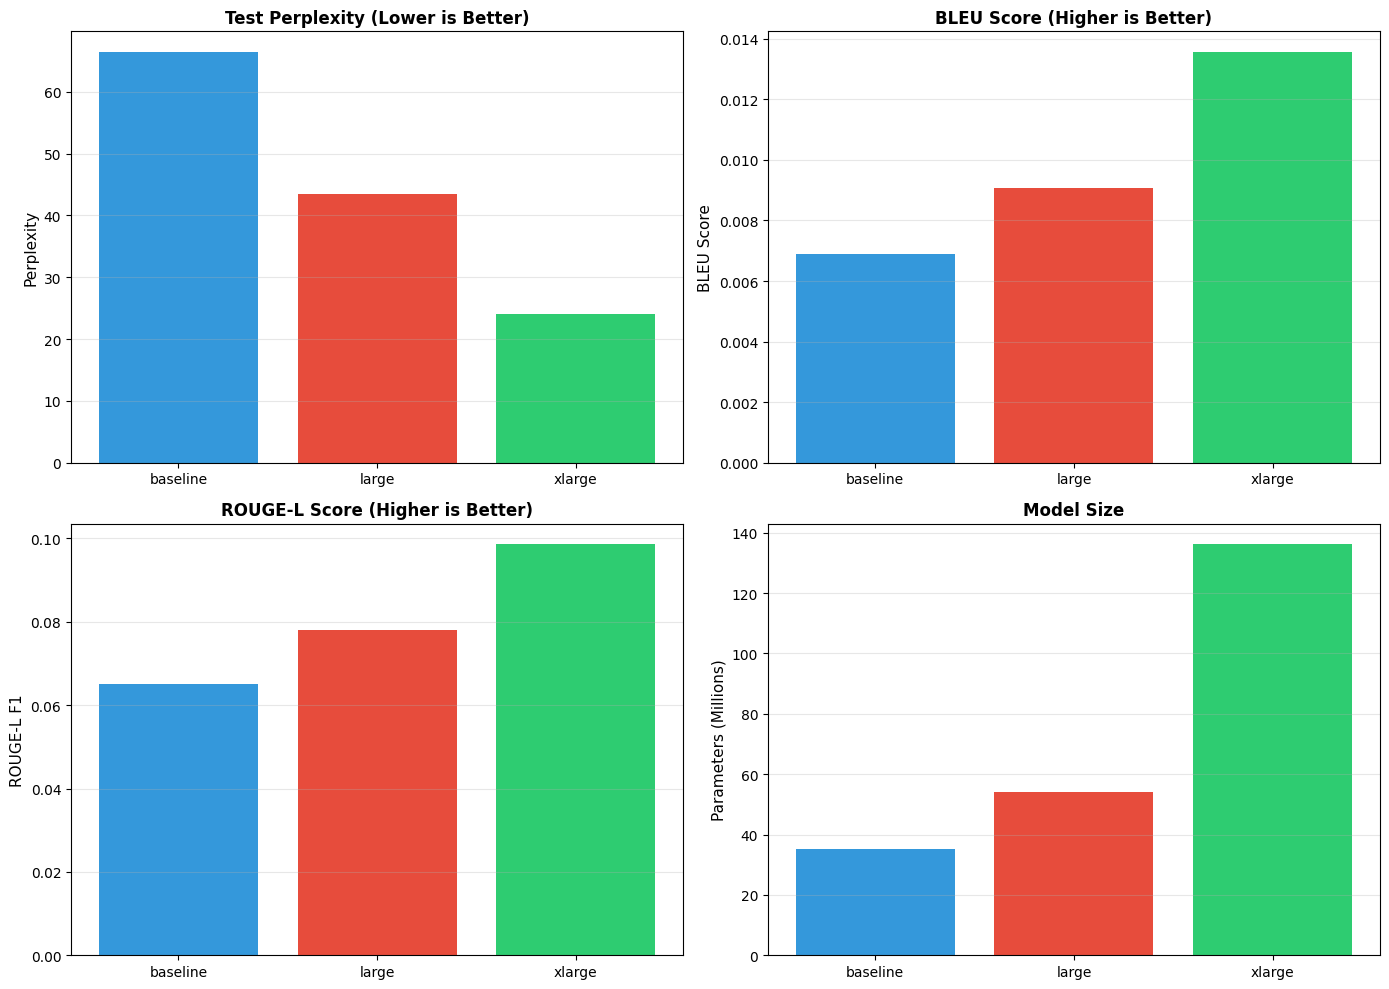



5. Best Model Recommendation:

  Best Perplexity: xlarge (24.01)
  Best BLEU Score: xlarge (0.0136)
  Best Validation Loss: xlarge (0.5411)


ANALYSIS COMPLETE!

Saved files:
  • best_baseline_model.pt
  • final_baseline_model.pt
  • training_curves_baseline.png
  • best_large_model.pt
  • final_large_model.pt
  • training_curves_large.png
  • best_xlarge_model.pt
  • final_xlarge_model.pt
  • training_curves_xlarge.png
  • all_models_comparison.png
  • performance_metrics_comparison.png




In [ ]:
print("="*80)
print("COMPARATIVE ANALYSIS: ALL MODELS")
print("="*80 + "\n")

# Check available models
available_models = [m for m in configs_to_test.keys() if m in all_results and 'test_perplexity' in all_results[m]]
missing_models = [m for m in configs_to_test.keys() if m not in all_results or 'test_perplexity' not in all_results[m]]

if missing_models:
    print(f"⚠️  WARNING: Missing evaluation for: {', '.join(missing_models)}")
    print(f"Only analyzing: {', '.join(available_models)}\n")

if not available_models:
    print("ERROR: No evaluated models available. Please run training and evaluation first.")
else:
    # 1. Summary Table
    print("1. Model Comparison Summary:\n")
    comparison_data = []
    for config_name in available_models:
        results = all_results[config_name]
        comparison_data.append({
            'Model': config_name,
            'Parameters': f"{results['total_params']:,}",
            'Train Time (min)': f"{results['training_time']/60:.1f}",
            'Best Val Loss': f"{results['best_val_loss']:.4f}",
            'Final Train Loss': f"{results['final_train_loss']:.4f}",
            'Test Perplexity': f"{results['test_perplexity']:.2f}",
            'BLEU': f"{results['bleu_score']:.4f}",
            'ROUGE-L F1': f"{results['rouge_scores']['rouge-l']['f']:.4f}" if results['rouge_scores'] else 'N/A'
        })

    comparison_df = pd.DataFrame(comparison_data)
    print(comparison_df.to_string(index=False))

    # 2. Detailed Metrics Table
    print("\n\n2. Detailed Evaluation Metrics:\n")
    for config_name in available_models:
        results = all_results[config_name]
        print(f"\n{config_name.upper()}:")
        print(f"  Architecture: d_model={results['config'].d_model}, layers={results['config'].n_encoder_layers}")
        print(f"  Parameters: {results['total_params']:,}")
        print(f"  Best Validation Loss: {results['best_val_loss']:.4f}")
        print(f"  Test Perplexity: {results['test_perplexity']:.2f}")
        print(f"  BLEU Score: {results['bleu_score']:.4f}")
        if results['rouge_scores']:
            print(f"  ROUGE-1: {results['rouge_scores']['rouge-1']['f']:.4f}")
            print(f"  ROUGE-2: {results['rouge_scores']['rouge-2']['f']:.4f}")
            print(f"  ROUGE-L: {results['rouge_scores']['rouge-l']['f']:.4f}")
        print(f"  Avg Response Length: {results['length_stats']['mean_length']:.1f} tokens")

    # 3. Visualization: Training Curves Comparison
    print("\n\n3. Comparative Training Curves:")
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Training loss comparison
    for config_name in available_models:
        results = all_results[config_name]
        axes[0].plot(results['train_losses'], label=f"{config_name} ({results['total_params']:,} params)", linewidth=2)

    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Training Loss', fontsize=12)
    axes[0].set_title('Training Loss Comparison', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)

    # Validation loss comparison
    for config_name in available_models:
        results = all_results[config_name]
        eval_every = results['config'].eval_every
        val_epochs = list(range(eval_every-1, len(results['train_losses']), eval_every))
        axes[1].plot(val_epochs[:len(results['val_losses'])], results['val_losses'],
                     label=config_name, marker='o', linewidth=2, markersize=4)

    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Validation Loss', fontsize=12)
    axes[1].set_title('Validation Loss Comparison', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('all_models_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

    # 4. Visualization: Performance Metrics
    if len(available_models) > 1:
        print("\n4. Performance Metrics Comparison:")
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))

        # Perplexity
        perplexities = [all_results[m]['test_perplexity'] for m in available_models]
        colors = ['#3498db', '#e74c3c', '#2ecc71'][:len(available_models)]
        axes[0, 0].bar(available_models, perplexities, color=colors)
        axes[0, 0].set_ylabel('Perplexity', fontsize=11)
        axes[0, 0].set_title('Test Perplexity (Lower is Better)', fontsize=12, fontweight='bold')
        axes[0, 0].grid(True, alpha=0.3, axis='y')

        # BLEU Score
        bleu_scores = [all_results[m]['bleu_score'] for m in available_models]
        axes[0, 1].bar(available_models, bleu_scores, color=colors)
        axes[0, 1].set_ylabel('BLEU Score', fontsize=11)
        axes[0, 1].set_title('BLEU Score (Higher is Better)', fontsize=12, fontweight='bold')
        axes[0, 1].grid(True, alpha=0.3, axis='y')

        # ROUGE-L
        rouge_l_scores = [all_results[m]['rouge_scores']['rouge-l']['f'] if all_results[m]['rouge_scores'] else 0 for m in available_models]
        axes[1, 0].bar(available_models, rouge_l_scores, color=colors)
        axes[1, 0].set_ylabel('ROUGE-L F1', fontsize=11)
        axes[1, 0].set_title('ROUGE-L Score (Higher is Better)', fontsize=12, fontweight='bold')
        axes[1, 0].grid(True, alpha=0.3, axis='y')

        # Parameter count
        param_counts = [all_results[m]['total_params']/1e6 for m in available_models]  # in millions
        axes[1, 1].bar(available_models, param_counts, color=colors)
        axes[1, 1].set_ylabel('Parameters (Millions)', fontsize=11)
        axes[1, 1].set_title('Model Size', fontsize=12, fontweight='bold')
        axes[1, 1].grid(True, alpha=0.3, axis='y')

        plt.tight_layout()
        plt.savefig('performance_metrics_comparison.png', dpi=300, bbox_inches='tight')
        plt.show()
    else:
        print("\n4. Performance Metrics: Skipped (only 1 model available)")

    # 5. Best Model Recommendation
    print("\n\n5. Best Model Recommendation:")
    if len(available_models) > 1:
        best_perplexity = min([(m, all_results[m]['test_perplexity']) for m in available_models], key=lambda x: x[1])
        best_bleu = max([(m, all_results[m]['bleu_score']) for m in available_models], key=lambda x: x[1])
        best_val_loss = min([(m, all_results[m]['best_val_loss']) for m in available_models], key=lambda x: x[1])

        print(f"\n  Best Perplexity: {best_perplexity[0]} ({best_perplexity[1]:.2f})")
        print(f"  Best BLEU Score: {best_bleu[0]} ({best_bleu[1]:.4f})")
        print(f"  Best Validation Loss: {best_val_loss[0]} ({best_val_loss[1]:.4f})")
    else:
        model = available_models[0]
        results = all_results[model]
        print(f"\n  Only {model} model available:")
        print(f"    Perplexity: {results['test_perplexity']:.2f}")
        print(f"    BLEU Score: {results['bleu_score']:.4f}")
        print(f"    Validation Loss: {results['best_val_loss']:.4f}")

    print("\n\n" + "="*80)
    print("ANALYSIS COMPLETE!")
    print("="*80)
    print(f"\nSaved files:")
    for model in available_models:
        print(f"  • best_{model}_model.pt")
        print(f"  • final_{model}_model.pt")
        print(f"  • training_curves_{model}.png")
    print(f"  • all_models_comparison.png")
    if len(available_models) > 1:
        print(f"  • performance_metrics_comparison.png")
    print("\n")

In [ ]:
class PositionalEncoding(nn.Module):
    """Absolute positional encoding"""

    def __init__(self, d_model: int, dropout: float = 0.1, max_len: int = 5000):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer('pe', pe.unsqueeze(1))

    def forward(self, x):
        x = x + self.pe[:x.size(0)]
        return self.dropout(x)

class RelativePositionalBias(nn.Module):
    """Relative position bias for attention (T5-style)"""

    def __init__(self, n_heads: int, max_distance: int = 32):
        super().__init__()
        self.max_distance = max_distance
        self.relative_attention_bias = nn.Embedding(2 * max_distance + 1, n_heads)

    def forward(self, Q_len: int, K_len: int, device: torch.device):
        """Support both self-attention and cross-attention"""
        # For self-attention: Q_len == K_len
        # For cross-attention: Q_len might differ from K_len

        Q_positions = torch.arange(Q_len, device=device)
        K_positions = torch.arange(K_len, device=device)

        # Create relative positions: [Q_len, K_len]
        relative_positions = Q_positions.unsqueeze(1) - K_positions.unsqueeze(0)
        relative_positions = torch.clamp(relative_positions, -self.max_distance, self.max_distance)
        relative_positions = relative_positions + self.max_distance

        bias = self.relative_attention_bias(relative_positions)
        return bias.permute(2, 0, 1).unsqueeze(0)  # [1, n_heads, Q_len, K_len]

class MultiHeadAttention(nn.Module):
    """Multi-head attention with optional relative position bias"""

    def __init__(self, d_model: int, n_heads: int, dropout: float = 0.1,
                 use_relative_position: bool = False, max_distance: int = 32):
        super().__init__()
        assert d_model % n_heads == 0

        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

        self.dropout = nn.Dropout(dropout)
        self.attention_weights = None

        self.use_relative_position = use_relative_position
        if use_relative_position:
            self.relative_bias = RelativePositionalBias(n_heads, max_distance)

    def forward(self, Q, K, V, mask=None):
        Q_len, batch_size, _ = Q.size()
        K_len, _, _ = K.size()

        Q = self.W_q(Q).view(Q_len, batch_size, self.n_heads, self.d_k).permute(1, 2, 0, 3)
        K = self.W_k(K).view(K_len, batch_size, self.n_heads, self.d_k).permute(1, 2, 0, 3)
        V = self.W_v(V).view(K_len, batch_size, self.n_heads, self.d_k).permute(1, 2, 0, 3)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)

        # Add relative position bias
        if self.use_relative_position:
            rel_bias = self.relative_bias(Q_len, K_len, Q.device)
            scores = scores + rel_bias

        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        attention_weights = F.softmax(scores, dim=-1)
        attention_weights = self.dropout(attention_weights)
        self.attention_weights = attention_weights.detach()

        context = torch.matmul(attention_weights, V)
        context = context.permute(2, 0, 1, 3).contiguous().view(Q_len, batch_size, self.d_model)

        return self.W_o(context)

class FeedForwardNetwork(nn.Module):
    """Position-wise feed-forward network"""

    def __init__(self, d_model: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.linear2(self.dropout(F.relu(self.linear1(x))))

class EncoderLayer(nn.Module):
    """Single encoder layer"""

    def __init__(self, d_model: int, n_heads: int, d_ff: int, dropout: float = 0.1,
                 use_relative_position: bool = False):
        super().__init__()
        self.self_attention = MultiHeadAttention(d_model, n_heads, dropout, use_relative_position)
        self.ffn = FeedForwardNetwork(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        attn_out = self.self_attention(x, x, x, mask)
        x = self.norm1(x + self.dropout(attn_out))
        ffn_out = self.ffn(x)
        x = self.norm2(x + self.dropout(ffn_out))
        return x

class DecoderLayer(nn.Module):
    """Single decoder layer with cross-attention"""

    def __init__(self, d_model: int, n_heads: int, d_ff: int, dropout: float = 0.1,
                 use_relative_position: bool = False):
        super().__init__()
        self.self_attention = MultiHeadAttention(d_model, n_heads, dropout, use_relative_position)
        self.cross_attention = MultiHeadAttention(d_model, n_heads, dropout, use_relative_position)
        self.ffn = FeedForwardNetwork(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, encoder_out, tgt_mask=None, src_mask=None):
        attn_out = self.self_attention(x, x, x, tgt_mask)
        x = self.norm1(x + self.dropout(attn_out))
        cross_attn_out = self.cross_attention(x, encoder_out, encoder_out, src_mask)
        x = self.norm2(x + self.dropout(cross_attn_out))
        ffn_out = self.ffn(x)
        x = self.norm3(x + self.dropout(ffn_out))
        return x

class TransformerEncoder(nn.Module):
    """Transformer encoder stack"""

    def __init__(self, vocab_size: int, d_model: int, n_heads: int, n_layers: int,
                 d_ff: int, dropout: float = 0.1, use_relative_position: bool = False):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.positional_encoding = PositionalEncoding(d_model, dropout)
        self.layers = nn.ModuleList([
            EncoderLayer(d_model, n_heads, d_ff, dropout, use_relative_position)
            for _ in range(n_layers)
        ])
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        x = self.embedding(x) * math.sqrt(self.embedding.embedding_dim)
        x = self.positional_encoding(x)
        for layer in self.layers:
            x = layer(x, mask)
        return x

class TransformerDecoder(nn.Module):
    """Transformer decoder stack"""

    def __init__(self, vocab_size: int, d_model: int, n_heads: int, n_layers: int,
                 d_ff: int, dropout: float = 0.1, use_relative_position: bool = False):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.positional_encoding = PositionalEncoding(d_model, dropout)
        self.layers = nn.ModuleList([
            DecoderLayer(d_model, n_heads, d_ff, dropout, use_relative_position)
            for _ in range(n_layers)
        ])
        self.output_projection = nn.Linear(d_model, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, encoder_out, tgt_mask=None, src_mask=None):
        x = self.embedding(x) * math.sqrt(self.embedding.embedding_dim)
        x = self.positional_encoding(x)
        for layer in self.layers:
            x = layer(x, encoder_out, tgt_mask, src_mask)
        return self.output_projection(x)

print("✓ Transformer components ready\n")


print("\n=== Component Dimension Tests ===")

# Test positional encoding
pe = PositionalEncoding(config.d_model, dropout=0.0)
test_input = torch.randn(10, 4, config.d_model)  # [seq, batch, d_model]
pe_out = pe(test_input)
print(f"PositionalEncoding: {test_input.shape} → {pe_out.shape}")

# Test multi-head attention
mha = MultiHeadAttention(config.d_model, config.n_heads, use_relative_position=True)
Q = K = V = torch.randn(10, 4, config.d_model)
attn_out = mha(Q, K, V)
print(f"MultiHeadAttention: {Q.shape} → {attn_out.shape}")
print(f"  Attention weights shape: {mha.attention_weights.shape}")

# Test encoder layer
enc_layer = EncoderLayer(config.d_model, config.n_heads, config.d_ff)
enc_out = enc_layer(test_input)
print(f"EncoderLayer: {test_input.shape} → {enc_out.shape}")

# Test decoder layer
dec_layer = DecoderLayer(config.d_model, config.n_heads, config.d_ff)
dec_out = dec_layer(test_input, enc_out)
print(f"DecoderLayer: {test_input.shape} → {dec_out.shape}")

class UrduTransformerChatbot(nn.Module):
    """Complete Transformer chatbot with advanced features"""

    def __init__(self, vocab_size: int, config: TrainingConfig):
        super().__init__()
        self.config = config
        self.pad_idx = 0

        self.encoder = TransformerEncoder(
            vocab_size, config.d_model, config.n_heads, config.n_encoder_layers,
            config.d_ff, config.dropout, config.use_relative_position
        )

        self.decoder = TransformerDecoder(
            vocab_size, config.d_model, config.n_heads, config.n_decoder_layers,
            config.d_ff, config.dropout, config.use_relative_position
        )

        self.vocab_size = vocab_size

    def create_src_mask(self, src):
        """Mask for padding in encoder - [batch_size, 1, 1, seq_len]"""
        mask = (src != self.pad_idx).transpose(0, 1)  # [batch_size, seq_len]
        return mask.unsqueeze(1).unsqueeze(1)  # [batch_size, 1, 1, seq_len]

    def create_tgt_mask(self, tgt):
        """Causal + padding mask for decoder - [batch_size, 1, tgt_len, tgt_len]"""
        tgt_len = tgt.size(0)
        batch_size = tgt.size(1)

        causal_mask = torch.triu(torch.ones(tgt_len, tgt_len, device=tgt.device), diagonal=1)
        causal_mask = (causal_mask == 0)

        pad_mask = (tgt != self.pad_idx).transpose(0, 1)  # [batch_size, seq_len]

        # Expand pad_mask to [batch_size, 1, tgt_len, tgt_len]
        pad_mask = pad_mask.unsqueeze(1).unsqueeze(1)  # [batch_size, 1, 1, seq_len]
        pad_mask = pad_mask.expand(batch_size, 1, tgt_len, tgt_len)

        # Causal mask already [tgt_len, tgt_len], expand to [1, 1, tgt_len, tgt_len]
        causal_mask = causal_mask.unsqueeze(0).unsqueeze(0)

        # Element-wise AND
        attention_mask = causal_mask & pad_mask

        return attention_mask

    def forward(self, src, tgt):
        src_mask = self.create_src_mask(src)
        tgt_mask = self.create_tgt_mask(tgt)

        encoder_out = self.encoder(src, src_mask)
        decoder_out = self.decoder(tgt, encoder_out, tgt_mask, src_mask)

        return decoder_out

    def generate(self, src, max_length=50, temperature=1.0, top_k=0, top_p=0.9):
        self.eval()

        with torch.no_grad():
            src_mask = self.create_src_mask(src)
            encoder_out = self.encoder(src, src_mask)

            batch_size = src.size(1)
            eos_id = 3  # Store as constant or pass from tokenizer
            bos_id = 2

            generated = torch.full((1, batch_size), bos_id, dtype=torch.long, device=src.device)

            for step in range(max_length - 1):
                tgt_mask = self.create_tgt_mask(generated)
                output = self.decoder(generated, encoder_out, tgt_mask, src_mask)

                # Get logits for last position only
                next_logits = output[-1, :, :] / temperature

                # CRITICAL: Ensure logits are within vocab bounds
                next_logits = next_logits[:, :self.vocab_size]

                # Apply top-k filtering
                if top_k > 0:
                    top_k = min(top_k, next_logits.size(-1))  # Safety check
                    indices_to_remove = next_logits < torch.topk(next_logits, top_k)[0][..., -1, None]
                    next_logits[indices_to_remove] = -float('Inf')

                # Apply nucleus (top-p) filtering
                if top_p < 1.0:
                    sorted_logits, sorted_indices = torch.sort(next_logits, descending=True)
                    cumsum_probs = torch.cumsum(F.softmax(sorted_logits, dim=-1), dim=-1)

                    sorted_indices_to_remove = cumsum_probs > top_p
                    sorted_indices_to_remove[..., 1:] = sorted_indices_to_remove[..., :-1].clone()
                    sorted_indices_to_remove[..., 0] = 0

                    # Use scatter to remove indices
                    indices_to_remove = sorted_indices_to_remove.scatter(1, sorted_indices, sorted_indices_to_remove)
                    next_logits[indices_to_remove] = -float('Inf')

                # Sample next token
                probs = F.softmax(next_logits, dim=-1)

                # Safety: ensure probs sum to 1
                probs = probs / probs.sum(dim=-1, keepdim=True)

                next_token = torch.multinomial(probs, num_samples=1)

                # CRITICAL: Clamp to valid vocabulary range
                next_token = torch.clamp(next_token, 0, self.vocab_size - 1)

                generated = torch.cat([generated, next_token.transpose(0, 1)], dim=0)

                # Check for EOS token
                if (next_token == eos_id).all():
                    break

            return generated

model = UrduTransformerChatbot(tokenizer.get_vocab_size(), config).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"Model created with {total_params:,} parameters\n")


print("\n=== Model Forward Pass Test ===")
test_batch = next(iter(train_loader))
src = test_batch['input'].transpose(0, 1).to(device)  # [seq, batch]
tgt = test_batch['target'].transpose(0, 1).to(device)

print(f"Input shapes:")
print(f"  src: {src.shape}")
print(f"  tgt: {tgt.shape}")

output = model(src, tgt[:-1])
print(f"\nOutput shape: {output.shape}")
print(f"Expected: [seq_len-1, batch_size, vocab_size]")
print(f"Expected: [{tgt.shape[0]-1}, {tgt.shape[1]}, {model.vocab_size}]")

# Test mask creation
src_mask = model.create_src_mask(src)
tgt_mask = model.create_tgt_mask(tgt)
print(f"\nMask shapes:")
print(f"  src_mask: {src_mask.shape}")
print(f"  tgt_mask: {tgt_mask.shape}")

print("\n=== Generation Test ===")
test_src = src[:, :1]  # Single sample
generated = model.generate(test_src, max_length=20, temperature=0.8)
print(f"Generated shape: {generated.shape}")
print(f"Generated text: {tokenizer.decode(generated[:, 0].cpu().tolist())}")

class AttentionRegularization:
    """Attention regularization for improved attention patterns"""

    @staticmethod
    def entropy_loss(attention_weights, target_entropy=None):
        eps = 1e-8
        entropy = -(attention_weights * torch.log(attention_weights + eps)).sum(dim=-1).mean()
        return -entropy if target_entropy is None else F.mse_loss(entropy, torch.tensor(target_entropy))

    @staticmethod
    def sparsity_loss(attention_weights, weight=0.1):
        return weight * attention_weights.abs().mean()

class EnhancedLabelSmoothingLoss(nn.Module):
    """Label smoothing with attention regularization"""

    def __init__(self, vocab_size: int, padding_idx: int, smoothing: float = 0.1,
                 entropy_weight: float = 0.01, sparsity_weight: float = 0.001):
        super().__init__()
        self.criterion = nn.KLDivLoss(reduction='sum')
        self.padding_idx = padding_idx
        self.vocab_size = vocab_size
        self.smoothing = smoothing
        self.entropy_weight = entropy_weight
        self.sparsity_weight = sparsity_weight
        self.regularizer = AttentionRegularization()

    def forward(self, pred, target, attention_weights=None):
        """
        pred: [seq_len * batch_size, vocab_size]
        target: [seq_len * batch_size]
        """
        with torch.no_grad():
            true_dist = torch.zeros_like(pred)
            true_dist.fill_(self.smoothing / (self.vocab_size - 2))
            true_dist.scatter_(1, target.data.unsqueeze(1), 1 - self.smoothing)
            true_dist[:, self.padding_idx] = 0
            mask = torch.nonzero(target.data == self.padding_idx)
            if mask.dim() > 0 and mask.numel() > 0:
                true_dist.index_fill_(0, mask.squeeze(), 0.0)

        ce_loss = self.criterion(F.log_softmax(pred, dim=-1), true_dist) / pred.size(0)
        total_loss = ce_loss

        if attention_weights is not None and self.training:
            entropy_loss = self.regularizer.entropy_loss(attention_weights)
            sparsity_loss = self.regularizer.sparsity_loss(attention_weights, self.sparsity_weight)
            total_loss = ce_loss + self.entropy_weight * entropy_loss + sparsity_loss

        return total_loss

class CurriculumLearning:
    """Curriculum learning: gradually increase sequence length"""

    def __init__(self, initial_length: int = 20, max_length: int = 50, epochs: int = 10):
        self.initial_length = initial_length
        self.max_length = max_length
        self.epochs = epochs

    def get_length_for_epoch(self, epoch: int) -> int:
        """Get sequence length for current epoch"""
        progress = min(epoch / self.epochs, 1.0)
        return int(self.initial_length + (self.max_length - self.initial_length) * progress)

def get_lr_scheduler(optimizer, warmup_steps):
    """Learning rate scheduler with warmup"""
    def lr_lambda(step):
        if step < warmup_steps:
            return float(step) / float(max(1, warmup_steps))
        return max(0.1, float(warmup_steps) / float(max(1, step)))
    return optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# Test loss calculation
print("\n=== Loss Function Test ===")
dummy_pred = torch.randn(100, tokenizer.get_vocab_size()).to(device)
dummy_target = torch.randint(0, tokenizer.get_vocab_size(), (100,)).to(device)

loss_no_attn = criterion(dummy_pred, dummy_target, None)
print(f"Loss without attention regularization: {loss_no_attn.item():.4f}")

dummy_attn = torch.softmax(torch.randn(2, 4, 20, 20), dim=-1).to(device)
loss_with_attn = criterion(dummy_pred, dummy_target, dummy_attn)
print(f"Loss with attention regularization: {loss_with_attn.item():.4f}")
print(f"Regularization delta: {(loss_with_attn - loss_no_attn).item():.4f}")

# Test curriculum learning
print("\n=== Curriculum Learning Test ===")
for epoch in [0, 10, 30, 69]:
    length = curriculum.get_length_for_epoch(epoch)
    print(f"Epoch {epoch:2d}: max_length = {length}")


train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=config.batch_size, shuffle=True, drop_last=True)

criterion = EnhancedLabelSmoothingLoss(
    vocab_size=tokenizer.get_vocab_size(),
    padding_idx=0,
    smoothing=config.label_smoothing,
    entropy_weight=config.attention_entropy_weight,
    sparsity_weight=config.attention_sparsity_weight
)

# Define optimizer FIRST
optimizer = optim.AdamW(
    model.parameters(),
    lr=config.learning_rate,
    betas=(0.9, 0.98),
    eps=1e-9,
    weight_decay=0.01
)

# Then scheduler
scheduler = get_lr_scheduler(optimizer, config.warmup_steps)

# Curriculum learning
curriculum = CurriculumLearning(
    initial_length=20,
    max_length=config.max_seq_length,
    epochs=config.num_epochs
)

print(f"Training setup ")
print(f"  Learning rate: {config.learning_rate}")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}\n")

# Verify optimizer and scheduler
print("\n=== Training Setup Verification ===")
print(f"Initial learning rate: {optimizer.param_groups[0]['lr']:.6f}")
print(f"Number of parameter groups: {len(optimizer.param_groups)}")

# Test scheduler warmup
print("\nLearning rate schedule (first 10 steps):")
for step in range(10):
    print(f"  Step {step}: lr = {optimizer.param_groups[0]['lr']:.6f}")
    scheduler.step()

# Reset optimizer for actual training
optimizer = optim.AdamW(model.parameters(), lr=config.learning_rate,
                        betas=(0.9, 0.98), eps=1e-9, weight_decay=0.01)
scheduler = get_lr_scheduler(optimizer, config.warmup_steps)

class AttentionAnalyzer:
    """Analyze attention patterns for fluency improvement"""

    def __init__(self, model, tokenizer, device):
        self.model = model
        self.tokenizer = tokenizer
        self.device = device

    def get_attention_weights(self, src, tgt):
        """Extract attention weights from model"""
        self.model.eval()
        with torch.no_grad():
            _ = self.model(src, tgt[:-1])

        attention_data = {}

        # Collect from decoder self-attention
        for i, layer in enumerate(self.model.decoder.layers):
            if hasattr(layer.self_attention, 'attention_weights'):
                attention_data[f'decoder_self_attn_layer_{i}'] = layer.self_attention.attention_weights
            if hasattr(layer.cross_attention, 'attention_weights'):
                attention_data[f'decoder_cross_attn_layer_{i}'] = layer.cross_attention.attention_weights

        return attention_data

    def visualize_attention_heatmap(self, src, tgt, layer_name='decoder_self_attn_layer_0', head=0):
        """Visualize attention heatmap for specific layer"""
        attn_data = self.get_attention_weights(src, tgt)

        if layer_name not in attn_data:
            print(f"Layer {layer_name} not found")
            return

        weights = attn_data[layer_name][0, head].cpu().numpy()  # [seq_len, seq_len]

        plt.figure(figsize=(10, 8))
        sns.heatmap(weights, cmap='Blues', cbar=True, square=True)
        plt.title(f'Attention Weights: {layer_name} (Head {head})')
        plt.xlabel('Keys')
        plt.ylabel('Queries')
        plt.tight_layout()
        plt.show()

    def analyze_attention_focus(self, attention_data):
        """Analyze what model attends to"""
        analysis = {}

        for layer_name, weights in attention_data.items():
            # Average over heads and batch: [seq_len, seq_len]
            avg_weights = weights.mean(dim=(0, 1))

            # Attention entropy (higher = more distributed)
            entropy = -(avg_weights * torch.log(avg_weights + 1e-8)).sum()

            # Peak attention positions
            peak_positions = torch.topk(avg_weights.sum(dim=0), k=3)[1].tolist()

            analysis[layer_name] = {
                'entropy': entropy.item(),
                'peak_positions': peak_positions,
                'avg_max_attention': avg_weights.max().item()
            }

        return analysis

print("✓ Attention Analyzer ready\n")

class LengthControlledGeneration:
    """Control response length for improved fluency"""

    def __init__(self, model, tokenizer, device):
        self.model = model
        self.tokenizer = tokenizer
        self.device = device

    def generate_with_length_control(self, src, target_length=30, length_penalty=0.6,
                                     temperature=0.8, top_p=0.9):
        """
        Generate with length control
        length_penalty: higher = shorter responses
        """
        self.model.eval()

        with torch.no_grad():
            src_mask = self.model.create_src_mask(src)
            encoder_out = self.model.encoder(src, src_mask)

            batch_size = src.size(1)
            generated = torch.zeros(1, batch_size, dtype=torch.long, device=src.device)
            generated[0, :] = 2  # BOS

            for step in range(1, 60):
                tgt_mask = self.model.create_tgt_mask(generated)
                output = self.model.decoder(generated, encoder_out, tgt_mask, src_mask)

                logits = output[-1, :, :] / temperature

                # Length control: penalize continuation if approaching target length
                length_factor = 1.0 - (step / 60.0) * length_penalty
                if step > target_length:
                    logits[:, 3] = logits[:, 3] + 5.0  # Boost EOS token

                # Nucleus sampling
                sorted_logits, sorted_indices = torch.sort(logits, descending=True)
                cumsum = torch.cumsum(F.softmax(sorted_logits, dim=-1), dim=-1)
                sorted_indices_to_remove = cumsum > top_p
                sorted_indices_to_remove[..., 1:] = sorted_indices_to_remove[..., :-1].clone()
                sorted_indices_to_remove[..., 0] = 0
                logits[:, sorted_indices[sorted_indices_to_remove]] = -float('Inf')

                probs = F.softmax(logits, dim=-1)
                next_token = torch.multinomial(probs, 1)

                generated = torch.cat([generated, next_token.transpose(0, 1)], dim=0)

                if (next_token == 3).all():
                    break

        return generated

    def analyze_generation_patterns(self, src_list, num_samples=5):
        """Analyze response lengths across multiple samples"""
        lengths = []

        for src_encoded in src_list[:num_samples]:
            src = torch.tensor([src_encoded]).transpose(0, 1).to(self.device)
            generated = self.model.generate(src, max_length=50, temperature=0.8)

            # Count non-padding tokens
            length = (generated[:, 0] != 0).sum().item()
            lengths.append(length)

        print(f"Response Length Analysis (from {num_samples} samples):")
        print(f"  Mean length: {np.mean(lengths):.1f} tokens")
        print(f"  Std length: {np.std(lengths):.1f}")
        print(f"  Min: {min(lengths)}, Max: {max(lengths)}")

        return lengths

print("✓ Length Control Module ready\n")

class EnhancedTrainer:
    """Training with all advanced techniques"""

    def __init__(self, model, optimizer, criterion, scheduler, device, config, curriculum=None):
        self.model = model
        self.optimizer = optimizer
        self.criterion = criterion
        self.scheduler = scheduler
        self.device = device
        self.config = config
        self.curriculum = curriculum

        self.train_losses = []
        self.val_losses = []
        self.best_val_loss = float('inf')
        self.grad_accumulation_counter = 0

        self.scaler = GradScaler() if config.use_mixed_precision else None

    def collect_attention_weights(self):
        """Collect attention from all decoder layers"""
        weights_list = []
        for layer in self.model.decoder.layers:
            if hasattr(layer.cross_attention, 'attention_weights') and layer.cross_attention.attention_weights is not None:
                weights_list.append(layer.cross_attention.attention_weights)
        return torch.stack(weights_list).mean(dim=0) if weights_list else None



    def train_epoch(self, dataloader, epoch):
        """Train for one epoch with all techniques"""
        self.model.train()
        total_loss = 0
        self.optimizer.zero_grad()  # ✅ Reset gradients at epoch start
        self.grad_accumulation_counter = 0

        # Get curriculum length
        if self.config.use_curriculum_learning:
            current_max_len = curriculum.get_length_for_epoch(epoch)
        else:
            current_max_len = self.config.max_seq_length

        pbar = tqdm(dataloader, desc=f'Training Epoch {epoch+1}')
        for batch in pbar:
            src = batch['input'].transpose(0, 1).to(self.device)
            tgt = batch['target'].transpose(0, 1).to(self.device)

            # Curriculum learning
            if current_max_len < self.config.max_seq_length:
                src = src[:current_max_len]
                tgt = tgt[:current_max_len]

            tgt_input = tgt[:-1]
            tgt_output = tgt[1:]

            # Mixed precision training
            if self.config.use_mixed_precision and self.scaler:
                with autocast():
                    output = self.model(src, tgt_input)

                    attn_weights = None
                    if self.config.use_attention_regularization:
                        attn_weights = self.collect_attention_weights()

                    output_flat = output.reshape(-1, output.size(-1))
                    tgt_flat = tgt_output.reshape(-1)
                    loss = self.criterion(output_flat, tgt_flat, attn_weights)

                    if self.config.use_gradient_accumulation:
                        loss = loss / self.config.accumulation_steps

                self.scaler.scale(loss).backward()
            else:
                # Standard training (no mixed precision)
                output = self.model(src, tgt_input)

                attn_weights = None
                if self.config.use_attention_regularization:
                    attn_weights = self.collect_attention_weights()

                output_flat = output.reshape(-1, output.size(-1))
                tgt_flat = tgt_output.reshape(-1)
                loss = self.criterion(output_flat, tgt_flat, attn_weights)

                if self.config.use_gradient_accumulation:
                    loss = loss / self.config.accumulation_steps

                loss.backward()

            total_loss += loss.item() * (self.config.accumulation_steps if self.config.use_gradient_accumulation else 1)

            self.grad_accumulation_counter += 1
            if self.grad_accumulation_counter % self.config.accumulation_steps == 0:
                if self.config.use_mixed_precision and self.scaler:
                    self.scaler.unscale_(self.optimizer)
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.config.gradient_clip)
                    self.scaler.step(self.optimizer)
                    self.scaler.update()
                else:
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.config.gradient_clip)
                    self.optimizer.step()

                self.scheduler.step()
                self.optimizer.zero_grad()

            pbar.set_postfix({'loss': loss.item() * (self.config.accumulation_steps if self.config.use_gradient_accumulation else 1)})

        avg_loss = total_loss / len(dataloader)
        self.train_losses.append(avg_loss)
        return avg_loss

    def evaluate(self, dataloader):
        """Evaluate on validation set"""
        self.model.eval()
        total_loss = 0

        with torch.no_grad():
            for batch in tqdm(dataloader, desc='Validating'):
                src = batch['input'].transpose(0, 1).to(self.device)
                tgt = batch['target'].transpose(0, 1).to(self.device)

                tgt_input = tgt[:-1]
                tgt_output = tgt[1:]

                output = self.model(src, tgt_input)
                output_flat = output.reshape(-1, output.size(-1))
                tgt_flat = tgt_output.reshape(-1)

                loss = self.criterion(output_flat, tgt_flat, None)
                total_loss += loss.item()

        avg_loss = total_loss / len(dataloader)
        self.val_losses.append(avg_loss)
        return avg_loss

    def plot_training_curves(self, save_path=None):
        """Plot training progress"""
        fig, ax = plt.subplots(1, 1, figsize=(12, 6))

        ax.plot(self.train_losses, label='Train Loss', linewidth=2, color='blue')
        if self.val_losses:
            val_epochs = list(range(self.config.eval_every-1, len(self.train_losses), self.config.eval_every))
            ax.plot(val_epochs[:len(self.val_losses)], self.val_losses,
                   label='Val Loss', linewidth=2, color='red', marker='o')

        ax.set_xlabel('Epoch', fontsize=12)
        ax.set_ylabel('Loss', fontsize=12)
        ax.set_title('Training Progress', fontsize=14)
        ax.legend(fontsize=11)
        ax.grid(True, alpha=0.3)

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

trainer = EnhancedTrainer(model, optimizer, criterion, scheduler, device, config, curriculum)
print("✓ Enhanced Trainer ready\n")

class UrduChatbotInference:
    """Inference pipeline with multiple strategies"""

    def __init__(self, model, tokenizer, device):
        self.model = model
        self.tokenizer = tokenizer
        self.device = device
        self.model.eval()

    def chat(self, input_text, max_length=50, strategy='nucleus', temperature=0.8, target_length=None):
        """
        Generate response with different strategies
        strategy: 'greedy', 'beam', 'nucleus', 'length_controlled'
        """
        processed = processor.preprocess(input_text)
        src_encoded = tokenizer.encode(processed, add_special_tokens=True, max_length=config.max_seq_length)
        src = torch.tensor([src_encoded]).transpose(0, 1).to(self.device)

        with torch.no_grad():
            if strategy == 'greedy':
                generated = self.model.generate(src, max_length, temperature=0.0)
            elif strategy == 'beam':
                generated = self.model.generate(src, max_length, temperature=temperature, top_k=5)
            else:  # nucleus
                generated = self.model.generate(src, max_length, temperature=temperature, top_p=0.9)

        response_indices = generated[:, 0].cpu().tolist()
        response_text = tokenizer.decode(response_indices)

        return response_text

chatbot = UrduChatbotInference(model, tokenizer, device)

print("✓ Inference pipeline ready\n")


class UrduEvaluationMetrics:
    """Comprehensive evaluation"""

    def __init__(self, tokenizer):
        self.tokenizer = tokenizer

    def evaluate_fluency(self, model, test_loader, num_samples=50):
        """Generate predictions and evaluate"""
        model.eval()
        predictions = []
        references = []
        device = next(model.parameters()).device

        with torch.no_grad():
            for i, batch in enumerate(test_loader):
                if len(predictions) >= num_samples:
                    break

                src = batch['input'].transpose(0, 1).to(device)

                try:
                    generated = model.generate(src, max_length=50, temperature=0.8, top_p=0.9)

                    for j in range(src.size(1)):
                        pred_indices = generated[:, j].cpu().tolist()
                        pred_text = self.tokenizer.decode(pred_indices)
                        predictions.append(pred_text)

                        ref_text = batch['target_text'][j]
                        references.append(ref_text)

                        if len(predictions) >= num_samples:
                            break
                except Exception as e:
                    print(f"Error during generation: {e}")
                    continue

        return predictions, references

    def calculate_length_statistics(self, predictions):
        """Analyze response lengths"""
        lengths = [len(p.split()) for p in predictions]
        return {
            'mean_length': np.mean(lengths),
            'std_length': np.std(lengths),
            'min_length': min(lengths) if lengths else 0,
            'max_length': max(lengths) if lengths else 0
        }

    def calculate_bleu(self, predictions, references):
        """BLEU score for Urdu"""
        smoother = SmoothingFunction()
        scores = []
        for pred, ref in zip(predictions, references):
            score = sentence_bleu([ref.split()], pred.split(),
                                 smoothing_function=smoother.method1)
            scores.append(score)
        return np.mean(scores) if scores else 0.0

    def calculate_rouge(self, predictions, references):
        """ROUGE scores"""
        rouge = Rouge()
        try:
            # Filter out empty predictions/references
            valid_pairs = [(p, r) for p, r in zip(predictions, references) if p.strip() and r.strip()]
            if not valid_pairs:
                return None

            preds, refs = zip(*valid_pairs)
            scores = rouge.get_scores(list(preds), list(refs), avg=True)
            return scores
        except Exception as e:
            print(f"ROUGE calculation failed: {e}")
            return None

    def calculate_perplexity(self, model, dataloader, device):
        """Perplexity - standard LM metric"""
        model.eval()
        total_loss = 0
        total_tokens = 0
        pad_idx = 0

        with torch.no_grad():
            for batch in dataloader:
                src = batch['input'].transpose(0, 1).to(device)
                tgt = batch['target'].transpose(0, 1).to(device)

                tgt_input = tgt[:-1]
                tgt_output = tgt[1:]

                output = model(src, tgt_input)

                loss = F.cross_entropy(
                    output.reshape(-1, model.vocab_size),
                    tgt_output.reshape(-1),
                    ignore_index=pad_idx,
                    reduction='sum'
                )
                total_loss += loss.item()
                total_tokens += (tgt_output != pad_idx).sum().item()

        if total_tokens == 0:
            return float('inf')

        return math.exp(total_loss / total_tokens)

# Initialize evaluator
evaluator = UrduEvaluationMetrics(tokenizer)

# Resume training configuration
config_name = 'xlarge'
resume_from_epoch = 80  # The last completed epoch
total_epochs = 100  # Your target total epochs (adjust if needed)

print("="*80)
print("RESUMING TRAINING - XLARGE MODEL")
print("="*80)
print(f"Resuming from epoch: {resume_from_epoch}")
print(f"Training until epoch: {total_epochs}")

try:
    # Load the checkpoint
    checkpoint_path = f'checkpoint_{config_name}_epoch_{resume_from_epoch}.pt'
    print(f"\nLoading checkpoint: {checkpoint_path}")
    checkpoint = torch.load(checkpoint_path, map_location=device)

    # Recreate config
    config = TrainingConfig.xlarge()
    config.save_every = 20

    # Initialize model
    model = UrduTransformerChatbot(tokenizer.get_vocab_size(), config).to(device)
    model.load_state_dict(checkpoint['model_state_dict'])

    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(f"\nModel loaded successfully!")
    print(f"  Total parameters: {total_params:,}")
    print(f"  Trainable parameters: {trainable_params:,}")

    # Recreate dataloaders
    train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True, drop_last=True)
    val_loader = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=False, drop_last=True)
    test_loader = DataLoader(test_dataset, batch_size=config.batch_size, shuffle=False, drop_last=True)

    # Initialize training components
    criterion = EnhancedLabelSmoothingLoss(
        vocab_size=tokenizer.get_vocab_size(),
        padding_idx=0,
        smoothing=config.label_smoothing,
        entropy_weight=config.attention_entropy_weight,
        sparsity_weight=config.attention_sparsity_weight
    )

    optimizer = optim.AdamW(
        model.parameters(),
        lr=config.learning_rate,
        betas=(0.9, 0.98),
        eps=1e-9,
        weight_decay=0.01
    )

    # Load optimizer state
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

    scheduler = get_lr_scheduler(optimizer, config.warmup_steps)

    curriculum = CurriculumLearning(
        initial_length=20,
        max_length=config.max_seq_length,
        epochs=total_epochs
    )

    trainer = EnhancedTrainer(model, optimizer, criterion, scheduler, device, config, curriculum)

    # Restore training history
    trainer.train_losses = checkpoint.get('train_losses', [])
    trainer.val_losses = checkpoint.get('val_losses', [])

    # Load best validation loss if available
    try:
        best_model = torch.load(f'best_{config_name}_model.pt', map_location=device)
        trainer.best_val_loss = best_model['val_loss']
        print(f"Best validation loss so far: {trainer.best_val_loss:.4f}")
    except:
        print("No best model found, starting fresh validation tracking")
        trainer.best_val_loss = float('inf')

    print("\n" + "-"*80)
    print("RESUMING TRAINING")
    print("-"*80)

    # Continue training from next epoch
    start_time = datetime.now()

    for epoch in range(resume_from_epoch, total_epochs):
        epoch_start = datetime.now()

        # Get curriculum learning length
        if config.use_curriculum_learning:
            current_len = curriculum.get_length_for_epoch(epoch)
            curriculum_info = f" | Curriculum length: {current_len}"
        else:
            curriculum_info = ""

        print(f"\nEpoch {epoch+1}/{total_epochs}{curriculum_info}")

        # Train
        train_loss = trainer.train_epoch(train_loader, epoch)

        # Validate
        if (epoch + 1) % config.eval_every == 0:
            val_loss = trainer.evaluate(val_loader)
            epoch_time = (datetime.now() - epoch_start).total_seconds()
            current_lr = optimizer.param_groups[0]['lr']

            print(f"  Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
                  f"LR: {current_lr:.6f} | Time: {epoch_time:.1f}s")

            if val_loss < trainer.best_val_loss:
                trainer.best_val_loss = val_loss
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'config': asdict(config),
                    'val_loss': val_loss
                }, f'best_{config_name}_model.pt')
                print(f"  ✓ New best model saved! (Val Loss: {val_loss:.4f})")
        else:
            print(f"  Train Loss: {train_loss:.4f}")

        # Save checkpoint every 20 epochs
        if (epoch + 1) % config.save_every == 0:
            checkpoint = {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'config': asdict(config),
                'train_losses': trainer.train_losses,
                'val_losses': trainer.val_losses
            }
            torch.save(checkpoint, f'checkpoint_{config_name}_epoch_{epoch+1}.pt')
            print(f"  ✓ Checkpoint saved at epoch {epoch+1}")

    training_time = (datetime.now() - start_time).total_seconds()

    print("\n" + "-"*80)
    print(f"TRAINING COMPLETE - {config_name.upper()}")
    print("-"*80)
    print(f"Additional training time: {training_time/60:.2f} minutes")
    print(f"Best validation loss: {trainer.best_val_loss:.4f}")
    print(f"Final training loss: {trainer.train_losses[-1]:.4f}")

    # Save final model
    torch.save({
        'model_state_dict': model.state_dict(),
        'config': asdict(config),
        'train_losses': trainer.train_losses,
        'val_losses': trainer.val_losses,
        'best_val_loss': trainer.best_val_loss
    }, f'final_{config_name}_model.pt')

    # Store results
    all_results = {
        config_name: {
            'config': config,
            'total_params': total_params,
            'trainable_params': trainable_params,
            'training_time': training_time,
            'best_val_loss': trainer.best_val_loss,
            'final_train_loss': trainer.train_losses[-1],
            'train_losses': trainer.train_losses,
            'val_losses': trainer.val_losses,
            'model': model,
            'test_loader': test_loader
        }
    }

    # Plot training curves
    print("\nPlotting Training Curves...")
    trainer.plot_training_curves(save_path=f'training_curves_{config_name}_resumed.png')

    print(f"\n✓ Training resumed and completed successfully!")
    print(f"✓ Results stored (evaluation metrics pending)")

except FileNotFoundError as e:
    print(f"\n❌ ERROR: Checkpoint file not found!")
    print(f"Expected file: checkpoint_{config_name}_epoch_{resume_from_epoch}.pt")
    print(f"\nAvailable checkpoint files:")
    import glob
    checkpoints = glob.glob(f'checkpoint_{config_name}_epoch_*.pt')
    for cp in sorted(checkpoints):
        print(f"  - {cp}")

except Exception as e:
    print(f"\n❌ ERROR resuming training: {str(e)}")
    print(f"Traceback:\n{traceback.format_exc()}")

print("\n" + "="*80)
print("RESUME OPERATION COMPLETE")
print("="*80)